In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

df = pd.read_excel(r"C:\Users\ASUS\Downloads\PCOS_data_without_infertility.xlsx", sheet_name=1)

In [3]:
df.head(3)

,Sl. No,Patient File No.,PCOS (Y/N),Age (yrs),Weight (Kg),Height(Cm),BMI,Blood Group,Pulse rate(bpm),RR (breaths/min),...,Fast food (Y/N),Reg.Exercise(Y/N),BP _Systolic (mmHg),BP _Diastolic (mmHg),Follicle No. (L),Follicle No. (R),Avg. F size (L) (mm),Avg. F size (R) (mm),Endometrium (mm),Unnamed: 44
0,1,1,0,28,44.6,152.0,19.300000,15,78,22,...,1.0,0,110,80,3,3,18.0,18.0,8.5,NaN
1,2,2,0,36,65.0,161.5,24.921163,15,74,20,...,0.0,0,120,70,3,5,15.0,14.0,3.7,NaN
2,3,3,1,33,68.8,165.0,25.270891,11,72,18,...,1.0,0,120,80,13,15,18.0,20.0,10.0,NaN


In [4]:
df.describe()

,Sl. No,Patient File No.,PCOS (Y/N),Age (yrs),Weight (Kg),Height(Cm),BMI,Blood Group,Pulse rate(bpm),RR (breaths/min),...,Pimples(Y/N),Fast food (Y/N),Reg.Exercise(Y/N),BP _Systolic (mmHg),BP _Diastolic (mmHg),Follicle No. (L),Follicle No. (R),Avg. F size (L) (mm),Avg. F size (R) (mm),Endometrium (mm)
count,541.000000,541.000000,541.000000,541.000000,541.000000,541.000000,541.000000,541.000000,541.000000,541.000000,...,541.000000,540.000000,541.000000,541.000000,541.000000,541.000000,541.000000,541.000000,541.000000,541.000000
mean,271.000000,271.000000,0.327172,31.430684,59.637153,156.484835,24.311285,13.802218,73.247689,19.243993,...,0.489834,0.514815,0.247689,114.661738,76.927911,6.129390,6.641405,15.018115,15.451701,8.475915
std,156.317519,156.317519,0.469615,5.411006,11.028287,6.033545,4.056399,1.840812,4.430285,1.688629,...,0.500359,0.500244,0.432070,7.384556,5.574112,4.229294,4.436889,3.566839,3.318848,2.165381
min,1.000000,1.000000,0.000000,20.000000,31.000000,137.000000,12.417882,11.000000,13.000000,16.000000,...,0.000000,0.000000,0.000000,12.000000,8.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,136.000000,136.000000,0.000000,28.000000,52.000000,152.000000,21.641274,13.000000,72.000000,18.000000,...,0.000000,0.000000,0.000000,110.000000,70.000000,3.000000,3.000000,13.000000,13.000000,7.000000
50%,271.000000,271.000000,0.000000,31.000000,59.000000,156.000000,24.238227,14.000000,72.000000,18.000000,...,0.000000,1.000000,0.000000,110.000000,80.000000,5.000000,6.000000,15.000000,16.000000,8.500000
75%,406.000000,406.000000,1.000000,35.000000,65.000000,160.000000,26.634958,15.000000,74.000000,20.000000,...,1.000000,1.000000,0.000000,120.000000,80.000000,9.000000,10.000000,18.000000,18.000000,9.800000
max,541.000000,541.000000,1.000000,48.000000,108.000000,180.000000,38.900000,18.000000,82.000000,28.000000,...,1.000000,1.000000,1.000000,140.000000,100.000000,22.000000,20.000000,24.000000,24.000000,18.000000


### Understanding the Dataset
#### Patient File No. : This is the report number which has data for a particular patient
#### PCOS : Polycystic ovary syndrome (PCOS) is a hormonal disorder common among women of reproductive age, we would like to determine whether the patient has this syndrome or not
#### Age (yrs) : Age of patient in years
#### Weight (Kg) : Weight of patient in kg
#### Height(Cm) : Height of patient in centimeter
#### BMI : Body mass index of the patient
#### Blood Group : Blood Group of the patient A+ = 11, A- = 12, B+ = 13, B- = 14, O+ =15, O- = 16, AB+ =17, AB- = 18 (total 8 blood groups)
#### Pulse rate(bpm) : It is the heart rate of patient in beats per minute. Resting heart rate for adults ranges from 60 to 100 beats per minute
#### RR (breaths/min) : It is the respiration rate. Normal respiration rates for an adult person at rest range from 12 to 16 breaths per minute.
#### Hb(g/dl) : Hemoglobin levels in gram per deciliter. For women, a normal level ranges between 12.3 gm/dL and 15.3 gm/dL.
#### Cycle length(days) : This represents length of menstrual cycle. The length of the menstrual cycle varies from woman to woman, but the average is to have periods every 28 days.
#### Marraige Status (Yrs) : Years of marriage
#### Pregnant(Y/N) : If the patient is pregnant
#### No. of aborptions : No. of aborptions, if any. There are total 541 values out of which 437 patients never had any abortions.
#### I beta-HCG(mIU/mL) : this is case 1 of beta hcg
#### II beta-HCG(mIU/mL) : this is case 2 of beta hcg (please note: An beta hCG level of less than 5 mIU/mL is considered negative for pregnancy, and anything above 25 mIU/mL is considered positive for pregnancy) (also the unit mIU/mL is mili International Units per miliLiter)
#### FSH(mIU/mL) : Its full form is Follicle-stimulating hormone. During puberty: it ranges from 0.3 to 10.0 mIU/mL (0.3 to 10.0 IU/L) Women who are still menstruating: 4.7 to 21.5 mIU/mL (4.5 to 21.5 IU/L) After menopause: 25.8 to 134.8 mIU/mL (25.8 to 134.8 IU/L)
#### LH(mIU/mL) : It is Luteinizing Hormone.
#### FSH/LH : Ratio of FSH and LH
#### Hip(inch) : Hip size in inches
#### Waist(inch) : Waist Size in inches
#### Waist:Hip Ratio : Waist by hip ratio
#### TSH (mIU/L) : It is thyroid stimulating hormone. Normal values are from 0.4 to 4.0 mIU/L
#### AMH(ng/mL) : It is Anti-Mullerian Hormone.
#### PRL(ng/mL) : This represents Prolactin levels.
#### Vit D3 (ng/mL): Vitamin D levels. Normal vitamin D levels in the blood are 20 ng/ml or above for adults.
#### PRG(ng/mL): Progesterone levels
#### RBS(mg/dl): This value is obtained by doing Random Blood Sugar (RBS) Test.
#### Weight gain(Y/N): Is there been a weight gain
#### hair growth(Y/N): Is there been a hair growth
#### Skin darkening (Y/N): Skin darkening issues
#### Hair loss(Y/N): hair loss issues
#### Pimples(Y/N): pimples issues
#### Fast food (Y/N): is fast food part of you diet
#### Reg.Exercise(Y/N): do you do exercises on a regular basis
#### BP _Systolic (mmHg): Systolic blood pressure, measures the pressure in your arteries when your heart beats.
#### BP _Diastolic (mmHg): Diastolic blood pressure, measures the pressure in your arteries when your heart rests between beats.
#### Follicle No. (L): Follicles number in the left side
#### Follicle No. (R): Follicles number in the right side
#### Avg. F size (L) (mm): Average Follicle size in the left side in mm
#### Avg. F size (R) (mm): Average Follicle size in the right side in mm
#### Endometrium (mm): Size of Endometrium in mm

# **Data Preprocessing** 

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541 entries, 0 to 540
Data columns (total 45 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Sl. No                  541 non-null    int64  
 1   Patient File No.        541 non-null    int64  
 2   PCOS (Y/N)              541 non-null    int64  
 3    Age (yrs)              541 non-null    int64  
 4   Weight (Kg)             541 non-null    float64
 5   Height(Cm)              541 non-null    float64
 6   BMI                     541 non-null    float64
 7   Blood Group             541 non-null    int64  
 8   Pulse rate(bpm)         541 non-null    int64  
 9   RR (breaths/min)        541 non-null    int64  
 10  Hb(g/dl)                541 non-null    float64
 11  Cycle(R/I)              541 non-null    int64  
 12  Cycle length(days)      541 non-null    int64  
 13  Marraige Status (Yrs)   540 non-null    float64
 14  Pregnant(Y/N)           541 non-null    in

In [5]:
#Converting object data type to numeric type
df["AMH(ng/mL)"] = pd.to_numeric(df["AMH(ng/mL)"], errors="coerce") #converting object datatype to numeric
df["II    beta-HCG(mIU/mL)"] = pd.to_numeric(df["II    beta-HCG(mIU/mL)"], errors="coerce") #converting object datatypeTonumeric

In [6]:
df = df.rename(columns=lambda x: x.strip()) 

In [7]:
#dropping axes which are not useful
df = df.drop(['Unnamed: 44'], axis = 1) #dropping not useful axis
df = df.drop(['Sl. No'], axis = 1) #dropping not useful axis
df = df.drop(['Patient File No.'], axis = 1) #dropping not useful axis

In [9]:
df.head(3)

,PCOS (Y/N),Age (yrs),Weight (Kg),Height(Cm),BMI,Blood Group,Pulse rate(bpm),RR (breaths/min),Hb(g/dl),Cycle(R/I),...,Pimples(Y/N),Fast food (Y/N),Reg.Exercise(Y/N),BP _Systolic (mmHg),BP _Diastolic (mmHg),Follicle No. (L),Follicle No. (R),Avg. F size (L) (mm),Avg. F size (R) (mm),Endometrium (mm)
0,0,28,44.6,152.0,19.300000,15,78,22,10.48,2,...,0,1.0,0,110,80,3,3,18.0,18.0,8.5
1,0,36,65.0,161.5,24.921163,15,74,20,11.70,2,...,0,0.0,0,120,70,3,5,15.0,14.0,3.7
2,1,33,68.8,165.0,25.270891,11,72,18,11.80,2,...,1,1.0,0,120,80,13,15,18.0,20.0,10.0


<Axes: >

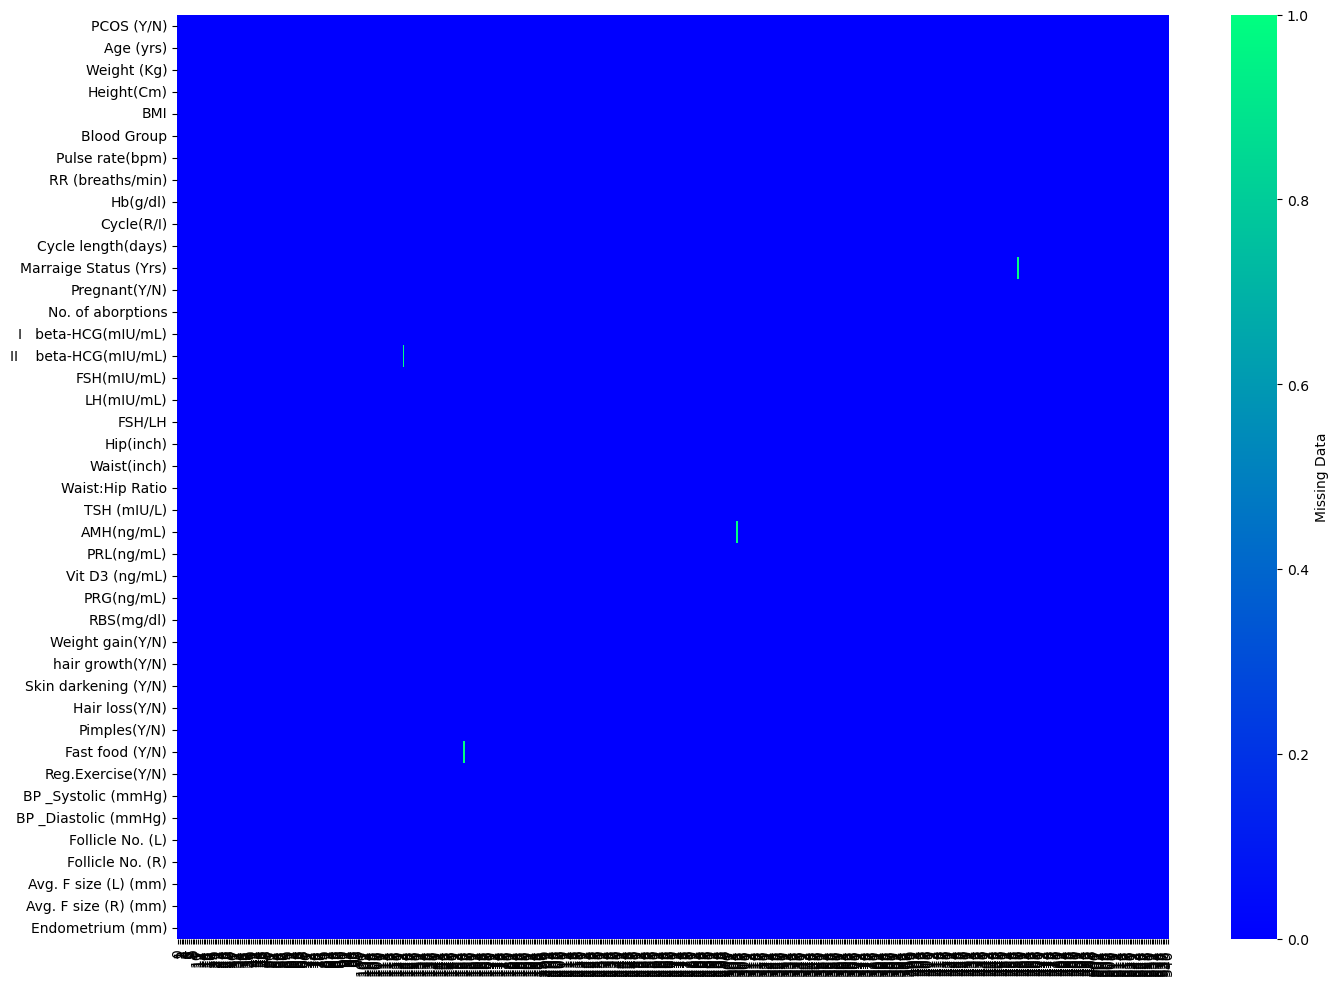

In [12]:
#plotting heatmap to visualize missing values
plt.figure(figsize=(16,12))
sns.heatmap(df.isna().transpose(),
            cmap="winter",
            cbar_kws={'label': 'Missing Data'}, xticklabels=True, yticklabels= True)

In [13]:
#column names with missing data
lst_missing_columns = df.columns[df.isna().any()].tolist()
lst_missing_columns


['Marraige Status (Yrs)',
 'II    beta-HCG(mIU/mL)',
 'AMH(ng/mL)',
 'Fast food (Y/N)']

In [14]:
#filling missing values with their median
for x in lst_missing_columns:
    df[x] = df[x].fillna(df[x].median())

In [15]:
#Verifying if any missing values are left
df.columns[df.isna().any()].tolist() #no more missing values left

[]

# **Visualization**

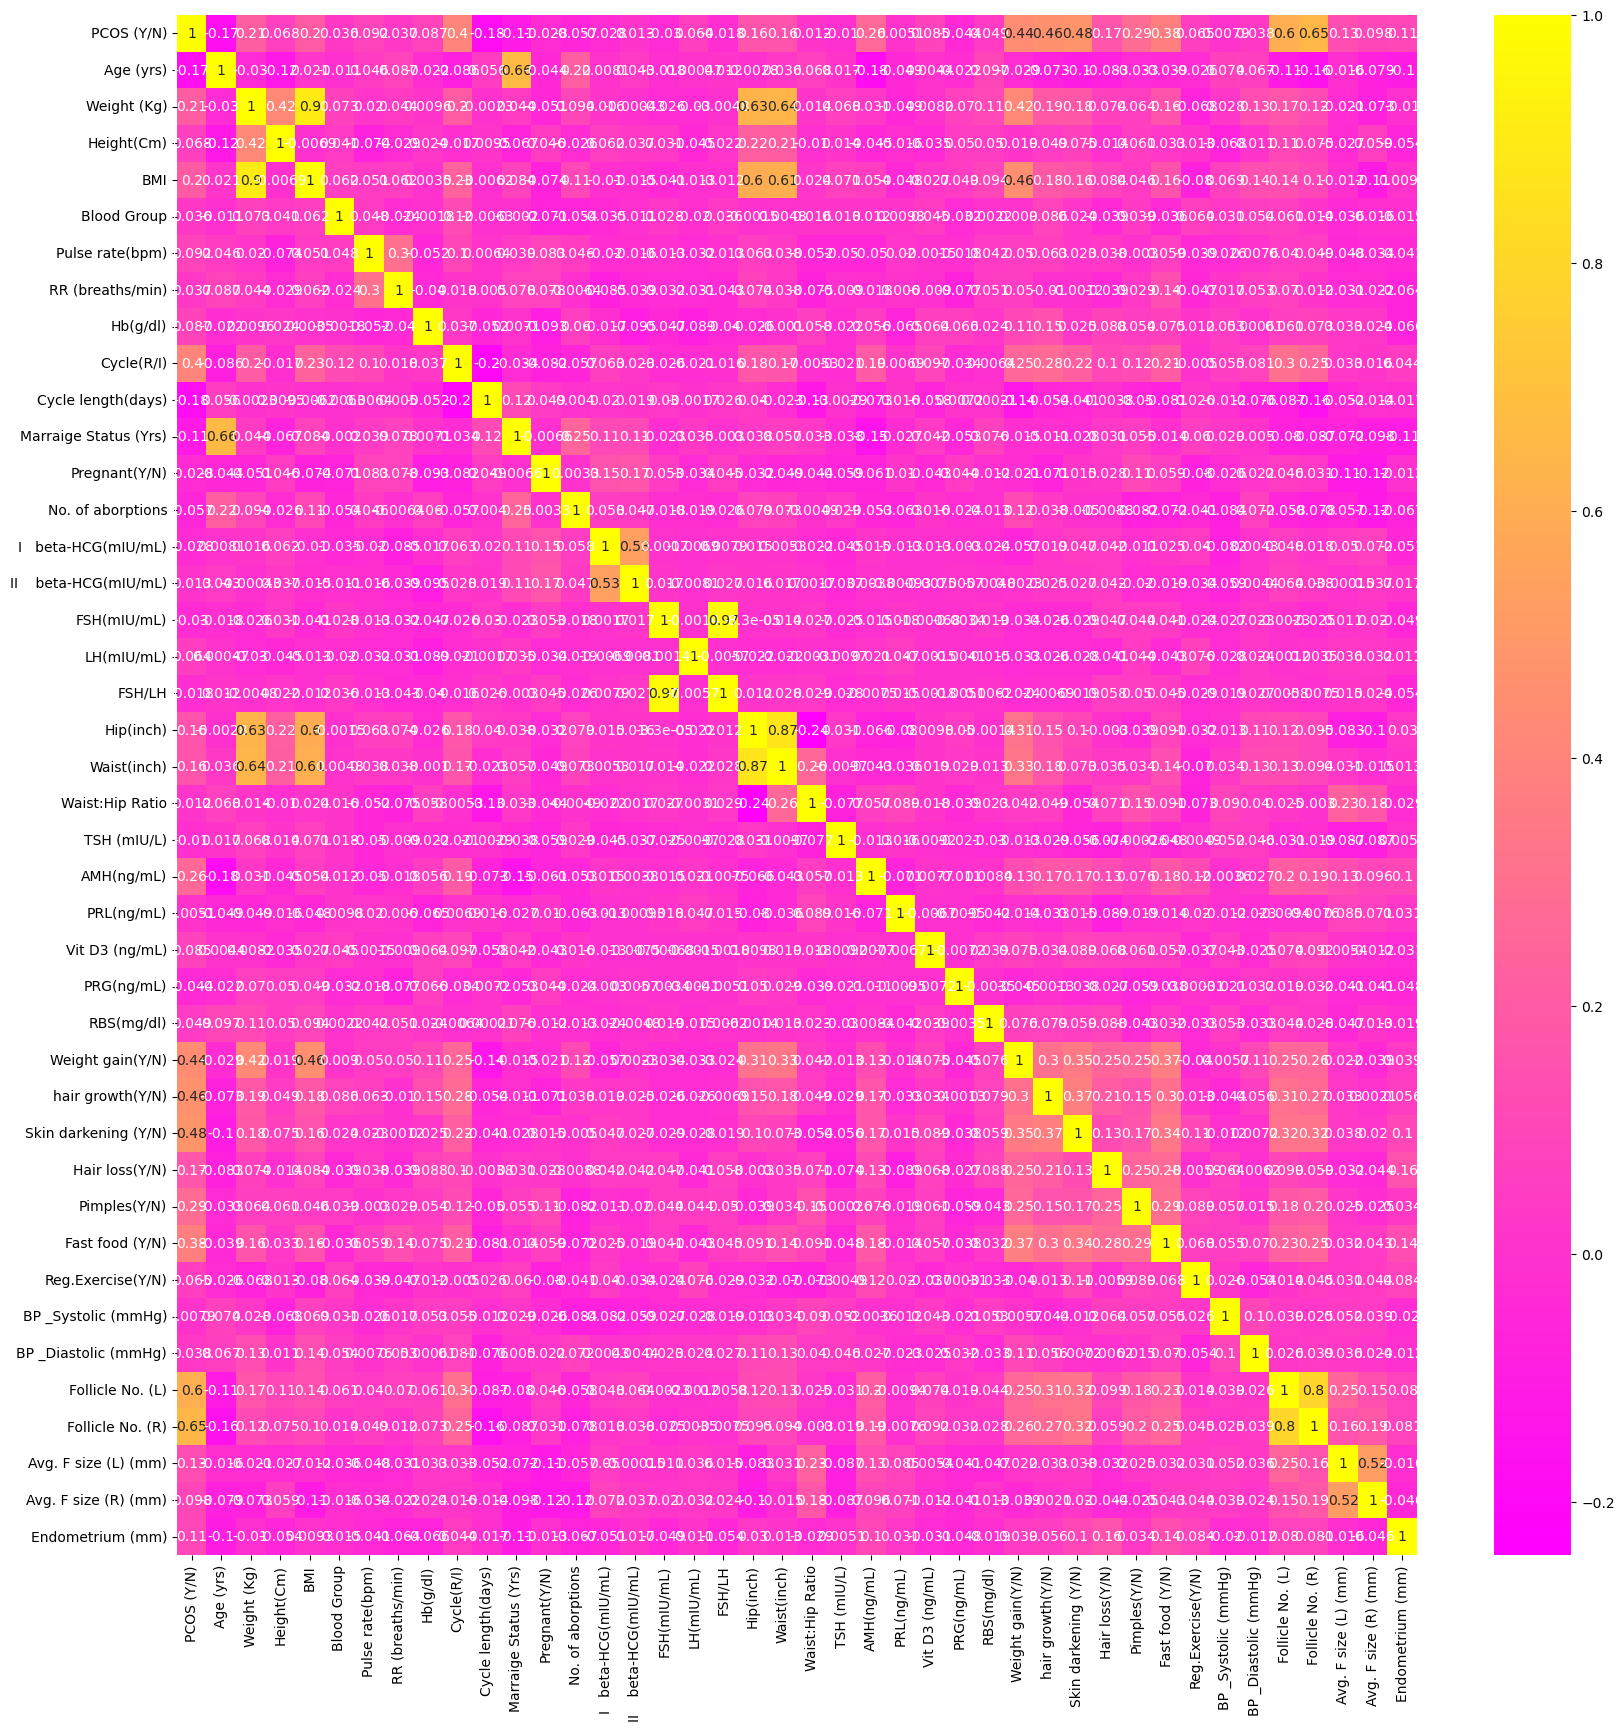

In [16]:
#Plotting correlation heatmap
plt.figure(figsize=(20, 20))
# plotting correlation heatmap
dataplot = sns.heatmap(df.corr(), cmap="spring", annot=True)

In [17]:
# displaying heatmap
plt.show()

In [18]:
#Checking how different features are correlated to PCOS
df.corr()["PCOS (Y/N)"].sort_values(ascending=False)

PCOS (Y/N)                1.000000
Follicle No. (R)          0.648327
Follicle No. (L)          0.603346
Skin darkening (Y/N)      0.475733
hair growth(Y/N)          0.464667
Weight gain(Y/N)          0.441047
Cycle(R/I)                0.401644
Fast food (Y/N)           0.376183
Pimples(Y/N)              0.286077
AMH(ng/mL)                0.264141
Weight (Kg)               0.211938
BMI                       0.199534
Hair loss(Y/N)            0.172879
Waist(inch)               0.164598
Hip(inch)                 0.162297
Avg. F size (L) (mm)      0.132992
Endometrium (mm)          0.106648
Avg. F size (R) (mm)      0.097690
Pulse rate(bpm)           0.091821
Hb(g/dl)                  0.087170
Vit D3 (ng/mL)            0.085494
Height(Cm)                0.068254
Reg.Exercise(Y/N)         0.065337
LH(mIU/mL)                0.063879
RBS(mg/dl)                0.048922
BP _Diastolic (mmHg)      0.038032
RR (breaths/min)          0.036928
Blood Group               0.036433
II    beta-HCG(mIU/m

In [19]:
#Identifying numerical and categorical features in dataframe
numerical_variables = []
categorical_variables = []
for x in df.columns:
    if len(df[x].value_counts()) < 9:
        if x not in ["RR (breaths/min)", "Cycle(R/I)", "No. of aborptions", "BP _Systolic (mmHg)", "BP _Diastolic (mmHg)"]:
            categorical_variables.append(x)
    else:
        numerical_variables.append(x)

In [20]:
categorical_variables

['PCOS (Y/N)',
 'Blood Group',
 'Pregnant(Y/N)',
 'Weight gain(Y/N)',
 'hair growth(Y/N)',
 'Skin darkening (Y/N)',
 'Hair loss(Y/N)',
 'Pimples(Y/N)',
 'Fast food (Y/N)',
 'Reg.Exercise(Y/N)']

In [21]:
numerical_variables

['Age (yrs)',
 'Weight (Kg)',
 'Height(Cm)',
 'BMI',
 'Pulse rate(bpm)',
 'Hb(g/dl)',
 'Cycle length(days)',
 'Marraige Status (Yrs)',
 'I   beta-HCG(mIU/mL)',
 'II    beta-HCG(mIU/mL)',
 'FSH(mIU/mL)',
 'LH(mIU/mL)',
 'FSH/LH',
 'Hip(inch)',
 'Waist(inch)',
 'Waist:Hip Ratio',
 'TSH (mIU/L)',
 'AMH(ng/mL)',
 'PRL(ng/mL)',
 'Vit D3 (ng/mL)',
 'PRG(ng/mL)',
 'RBS(mg/dl)',
 'Follicle No. (L)',
 'Follicle No. (R)',
 'Avg. F size (L) (mm)',
 'Avg. F size (R) (mm)',
 'Endometrium (mm)']

In [23]:
pcos_values = np.array([0, 0, 1, 0, 0])  # PCOS values (0: No, 1: Yes)
actual_bmi = np.array([19.3, 24.921163, 25.270891, 29.674945, 20.060954])
predicted_bmi = np.array([19.5, 24.8, 25.5, 30.0, 20.2])

In [24]:
# Calculate squared differences for individuals with PCOS
squared_diff_pcos = (actual_bmi[pcos_values == 1] - predicted_bmi[pcos_values == 1])**2

In [25]:
# Calculate squared differences for individuals without PCOS
squared_diff_no_pcos = (actual_bmi[pcos_values == 0] - predicted_bmi[pcos_values == 0])**2

In [26]:
# Calculate mean squared error for individuals with PCOS
mse_pcos = np.mean(squared_diff_pcos)

In [27]:
# Calculate mean squared error for individuals without PCOS
mse_no_pcos = np.mean(squared_diff_no_pcos)

In [28]:
print("Mean Squared Error (PCOS):", mse_pcos)
print("Mean Squared Error (No PCOS):", mse_no_pcos)

Mean Squared Error (PCOS): 0.05249093388100051
Mean Squared Error (No PCOS): 0.04491875392749975


In [31]:
# Filter the dataframe to include only patients with PCOS (PCOS (Y/N) == 1)
df_pcos = df[df['PCOS (Y/N)'] == 1]

In [32]:
# Define the list of features to plot
features_to_plot = ['Age (yrs)', 'Weight (Kg)', 'Height(Cm)', 'Hb(g/dl)', 'Cycle(R/I)',
                    'Cycle length(days)', 'No. of aborptions', 'Hip(inch)', 'Waist(inch)',
                    'PRG(ng/mL)', 'RBS(mg/dl)', 'BP _Systolic (mmHg)', 'Follicle No. (L)',
                    'Follicle No. (R)', 'Avg. F size (L) (mm)', 'Avg. F size (R) (mm)',
                    'Endometrium (mm)', 'BMI']

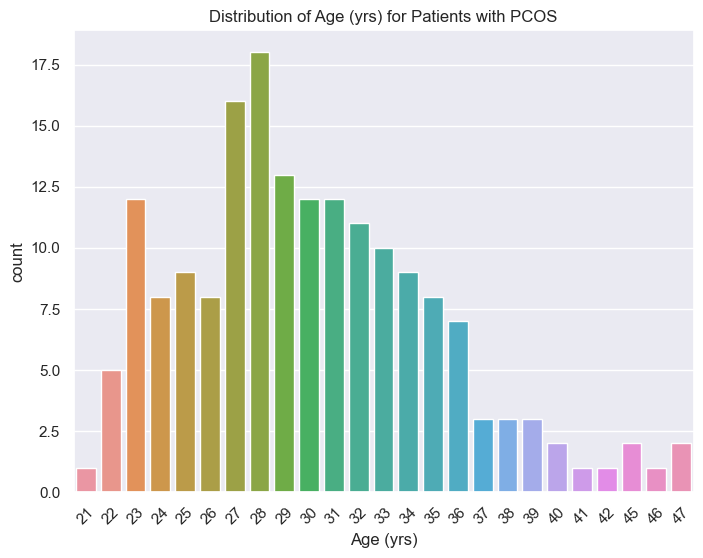

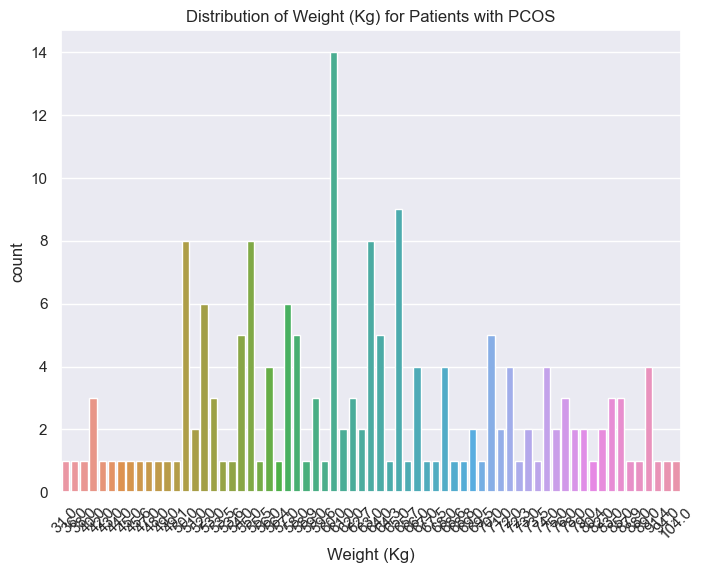

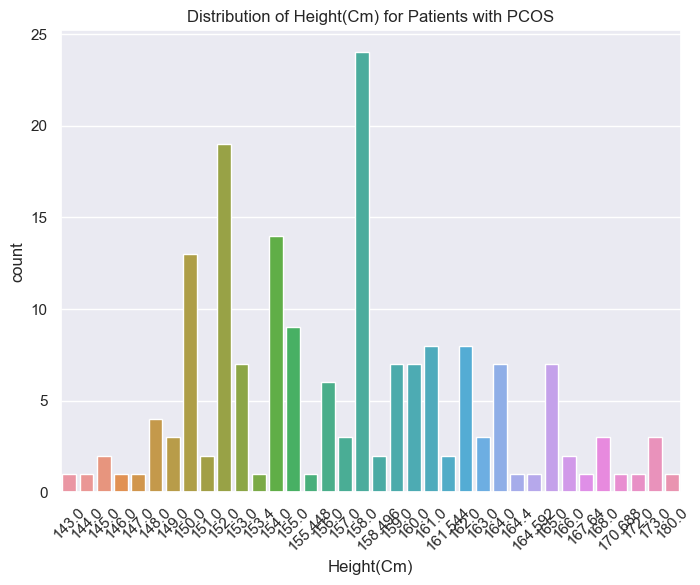

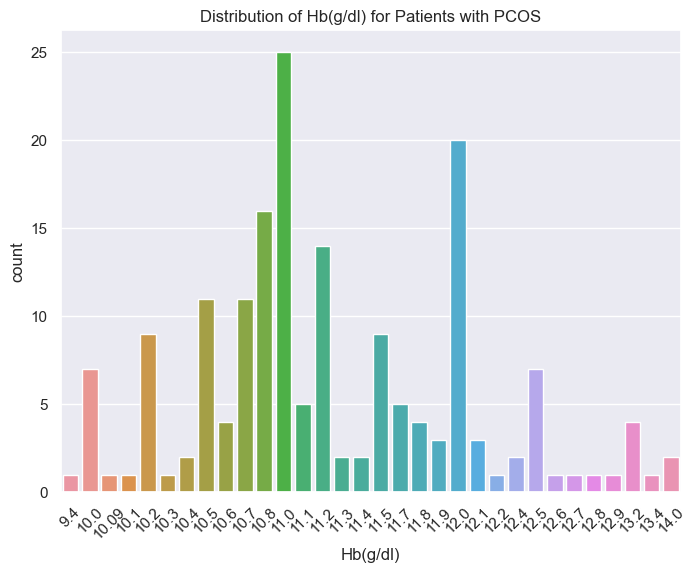

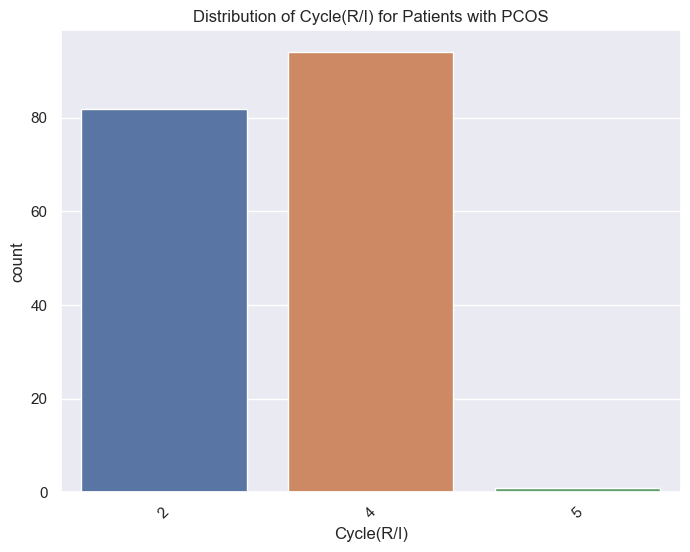

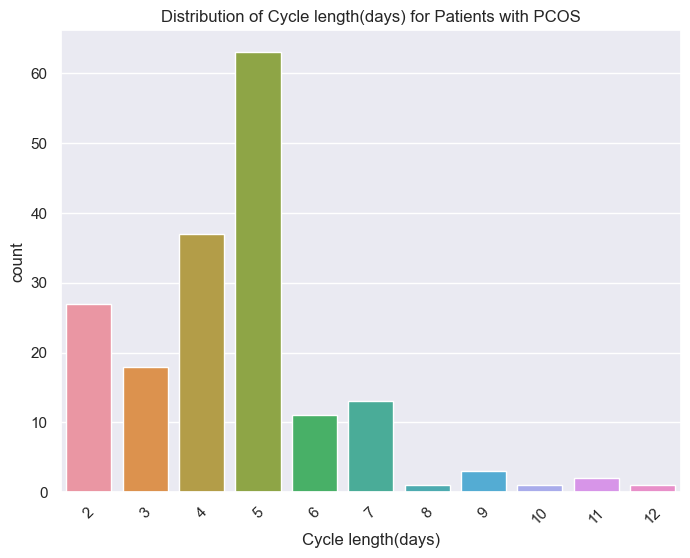

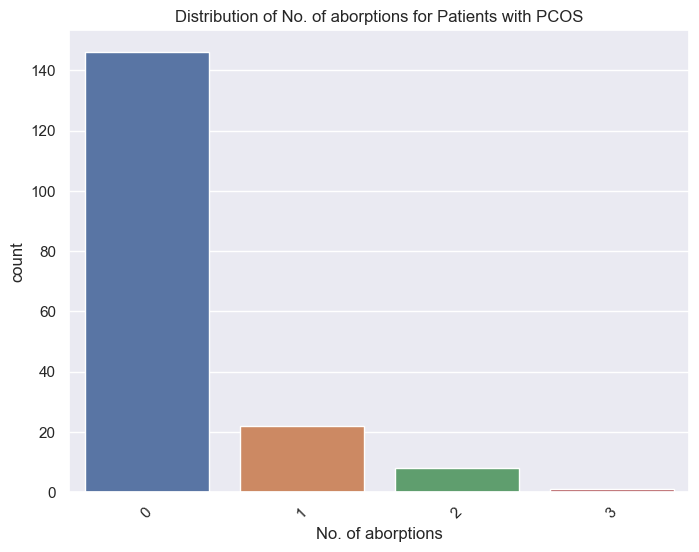

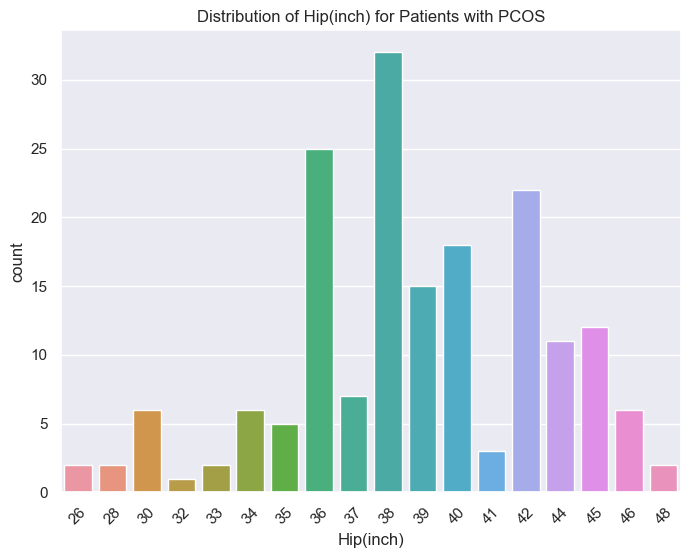

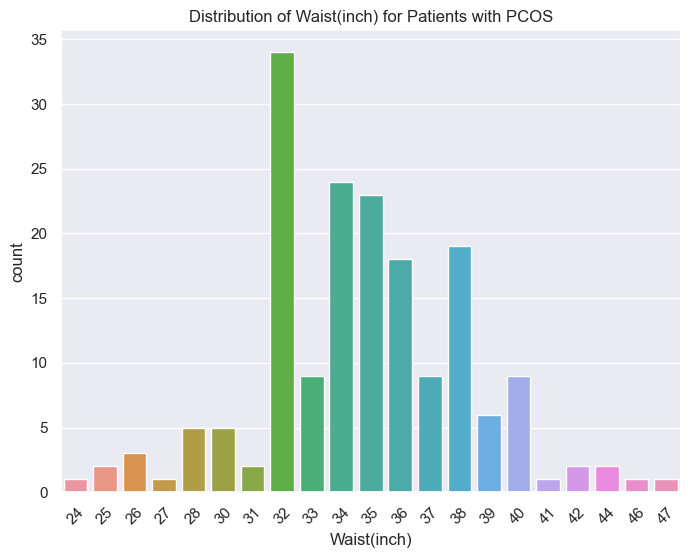

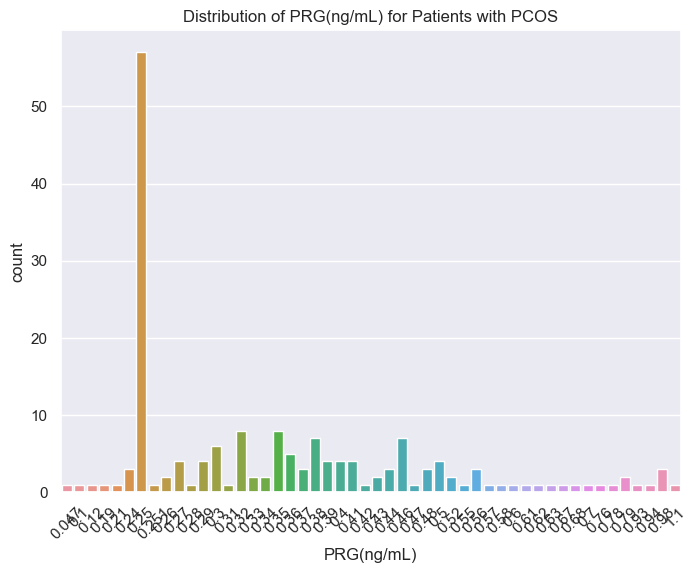

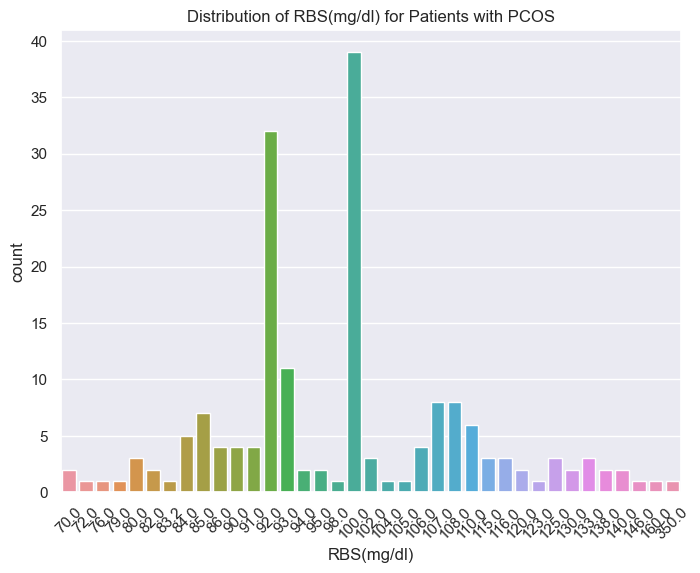

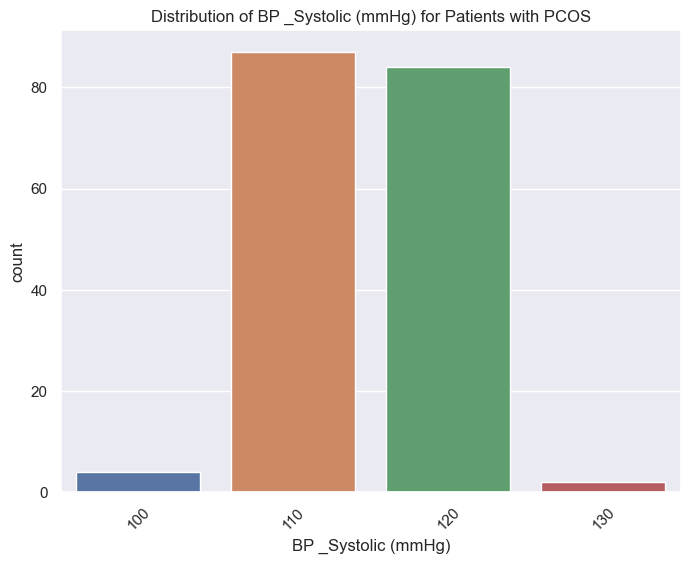

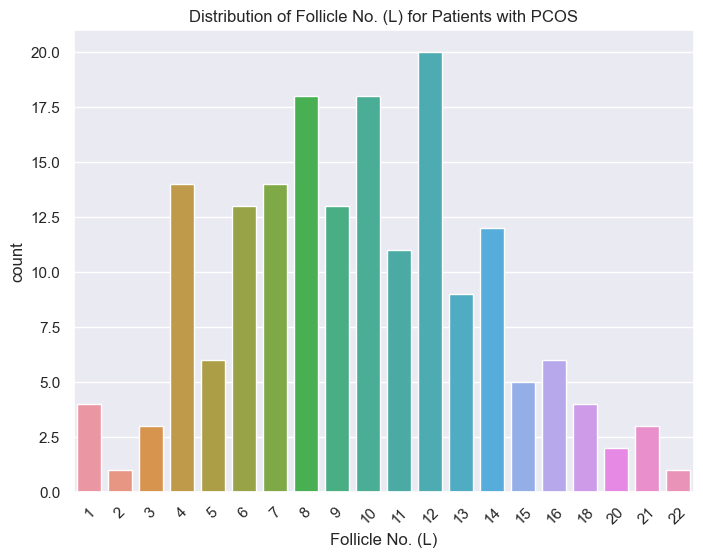

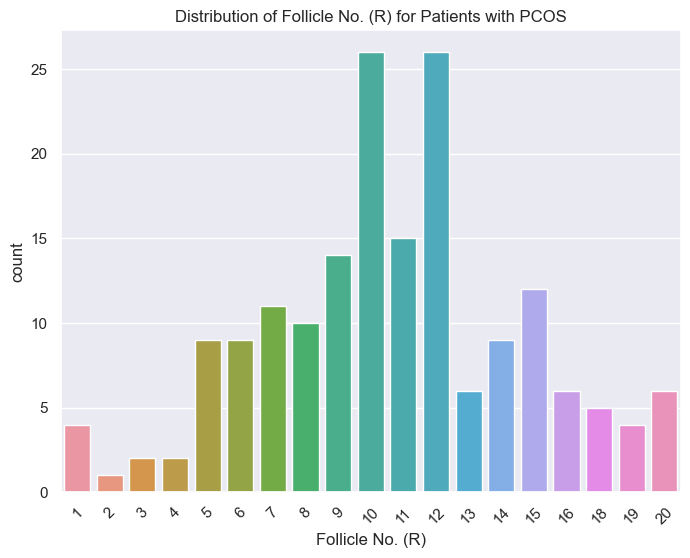

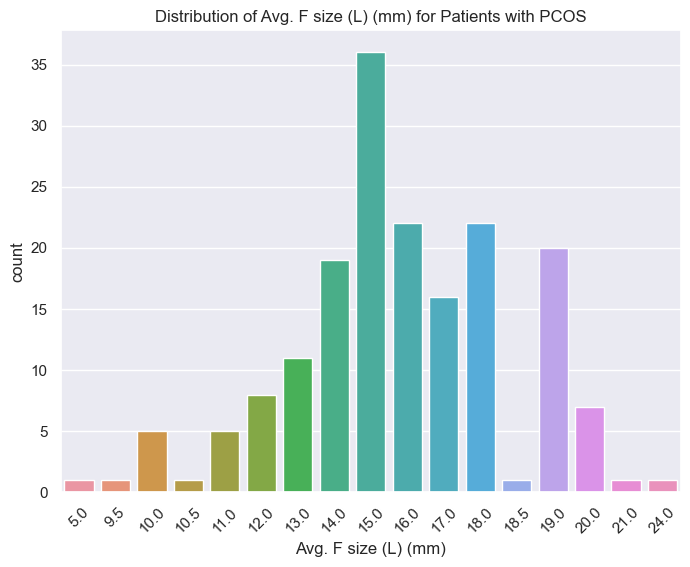

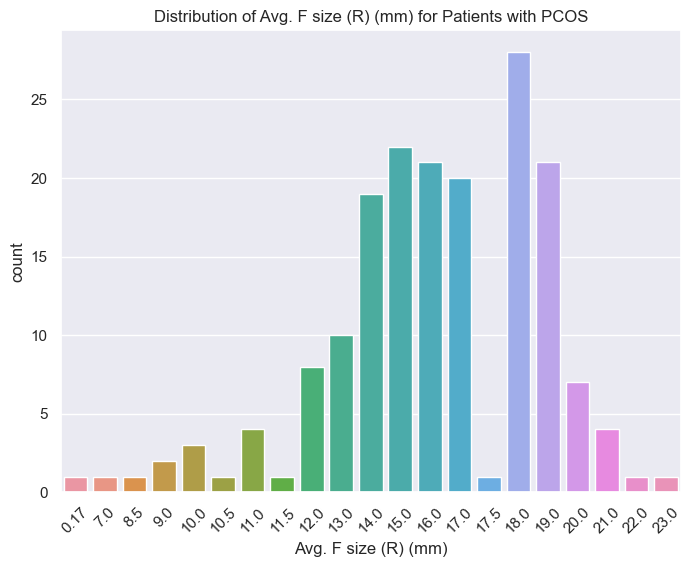

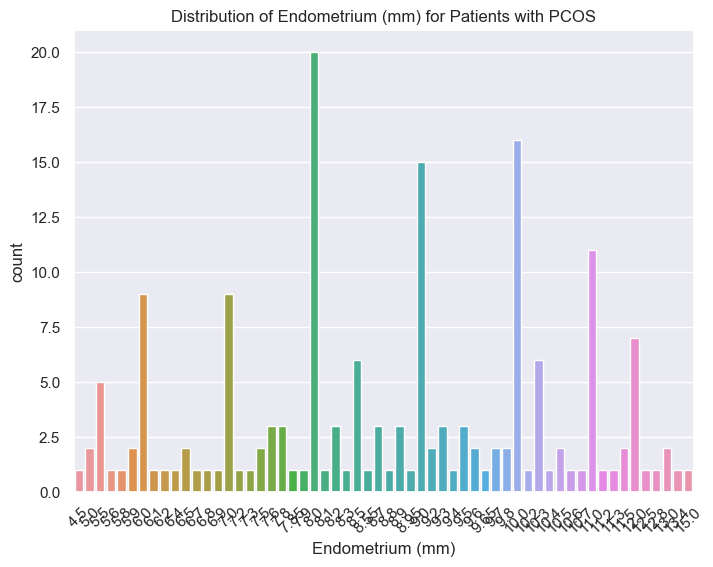

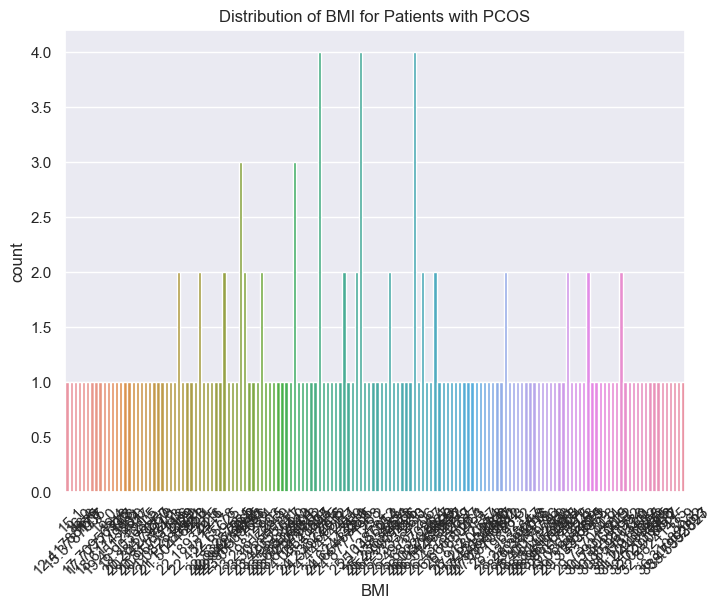

In [33]:
# Plot each feature separately
for i in features_to_plot:
    sns.set(rc={'figure.figsize': (8, 6)})  # Set the figure size
    sns.countplot(x=i, data=df_pcos)  # Use countplot for categorical features
    plt.title(f"Distribution of {i} for Patients with PCOS")
    plt.xticks(rotation=45)  # Rotate x-axis labels if needed
    plt.show()

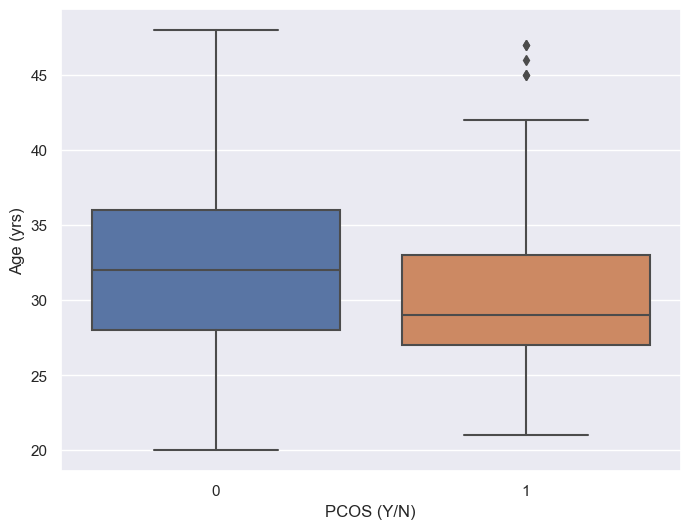

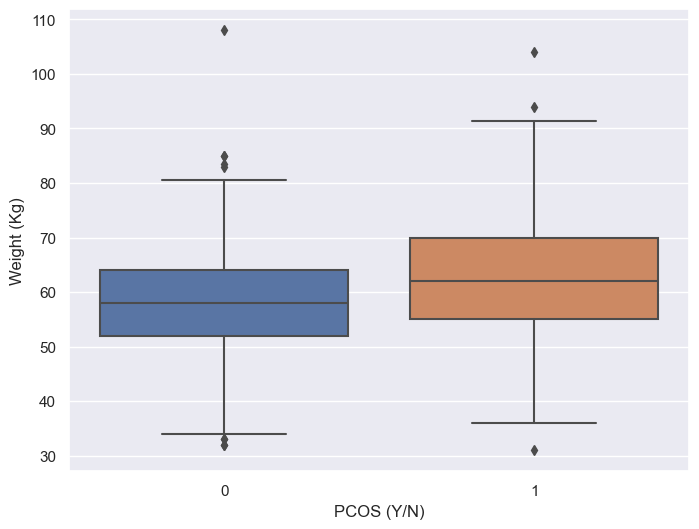

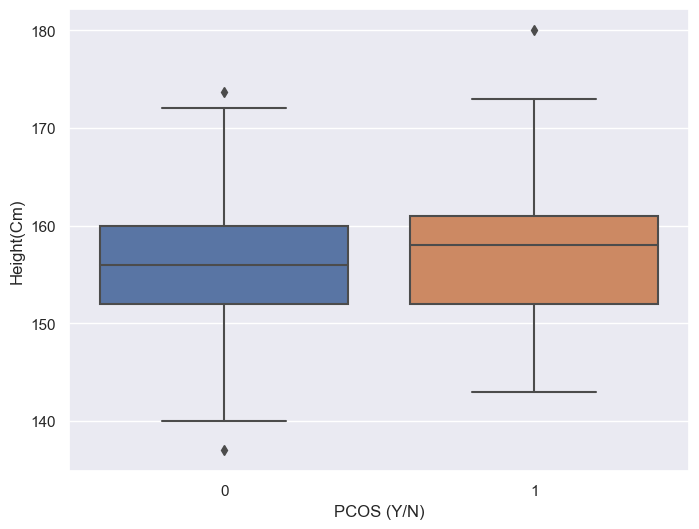

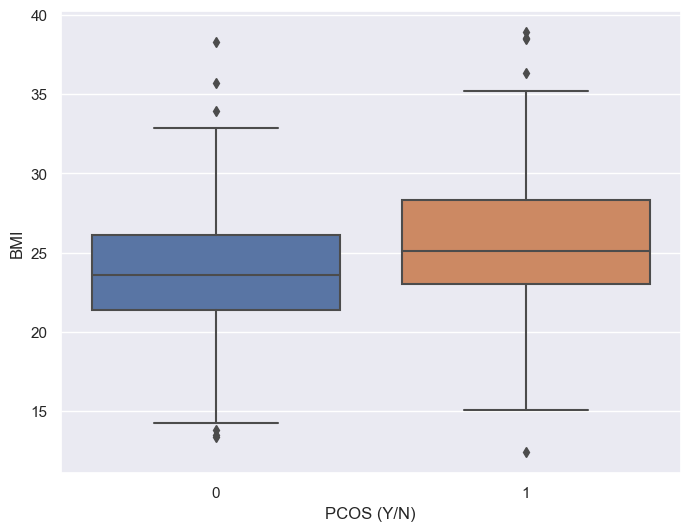

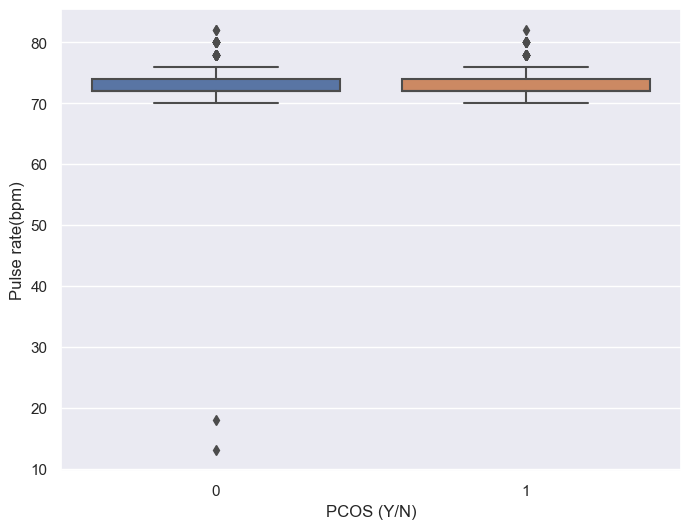

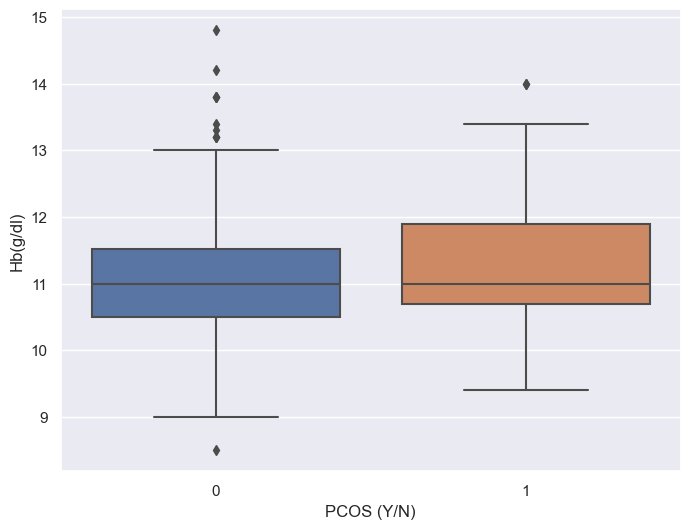

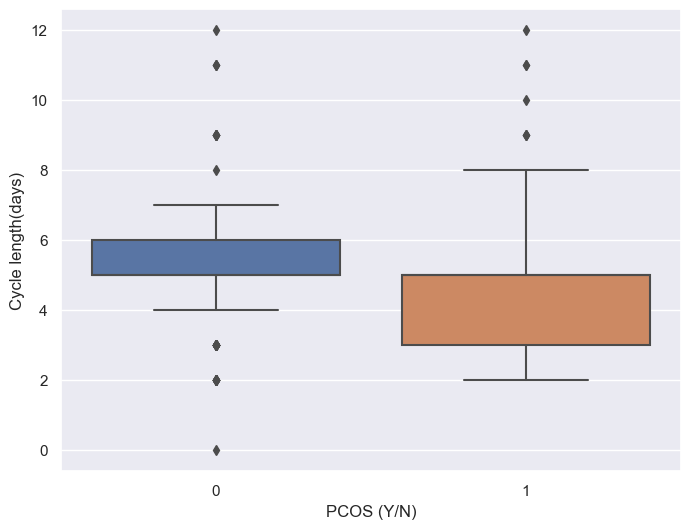

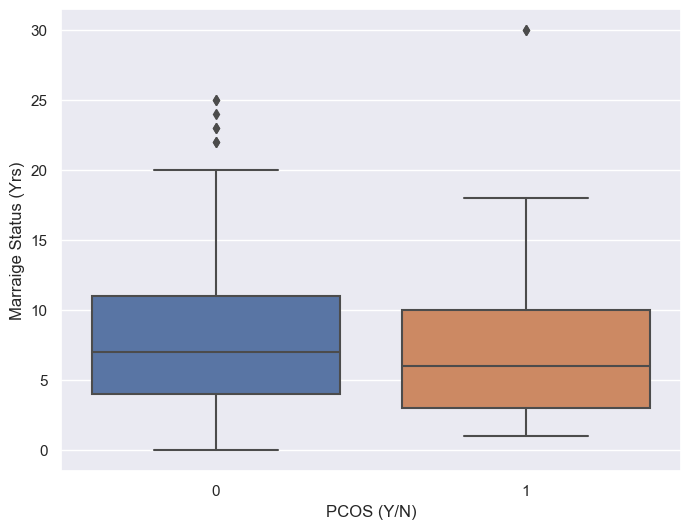

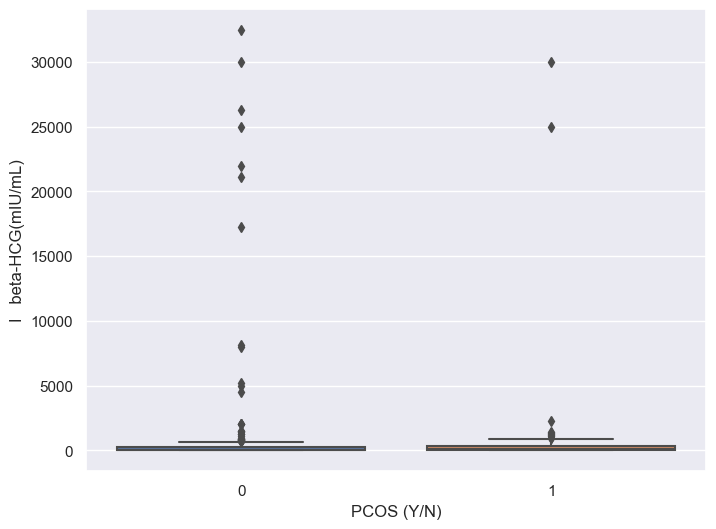

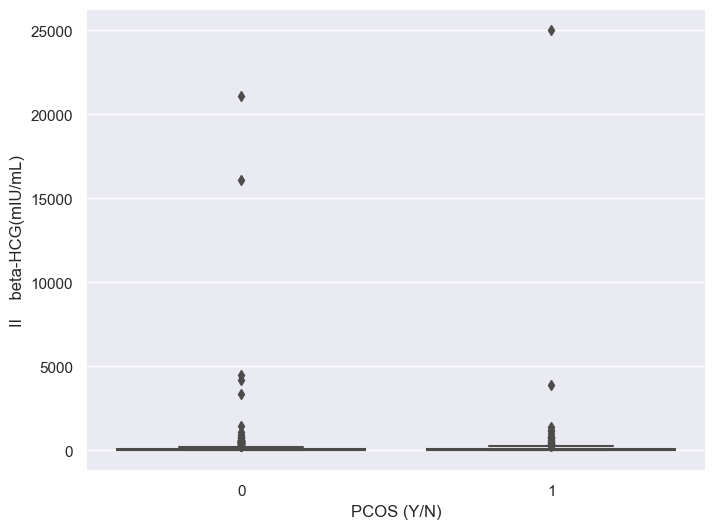

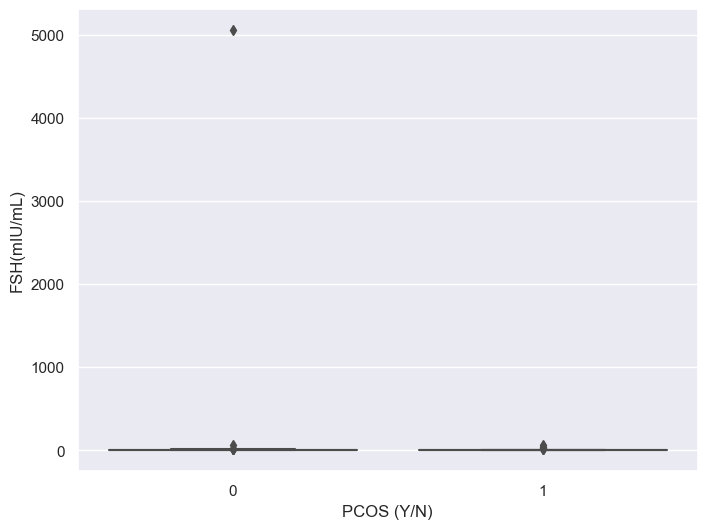

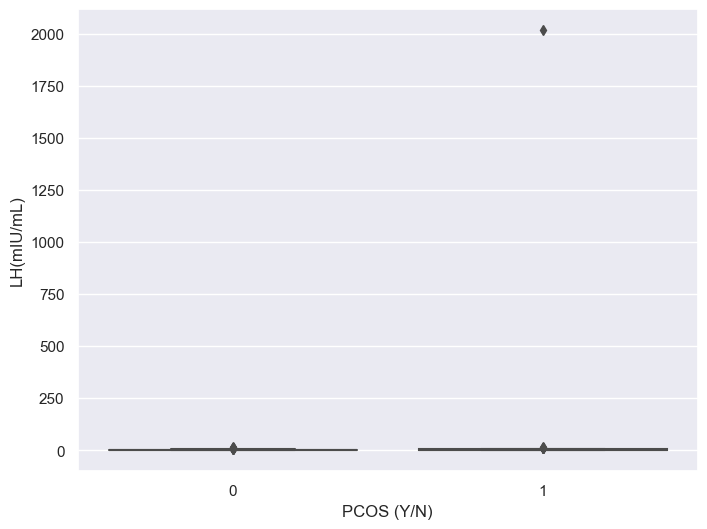

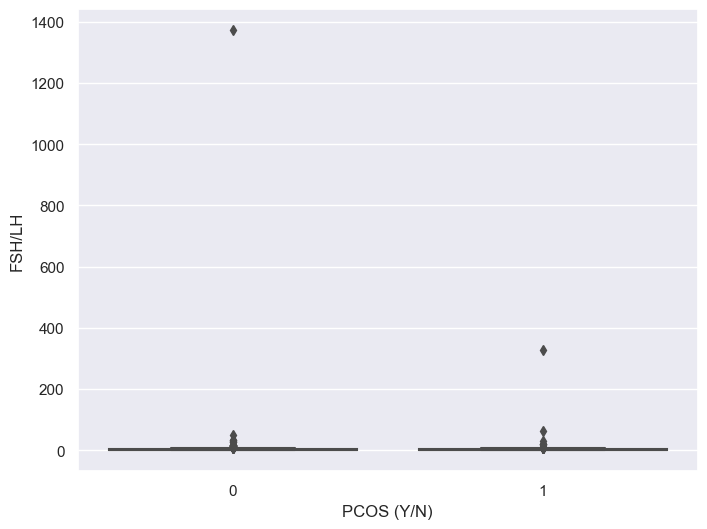

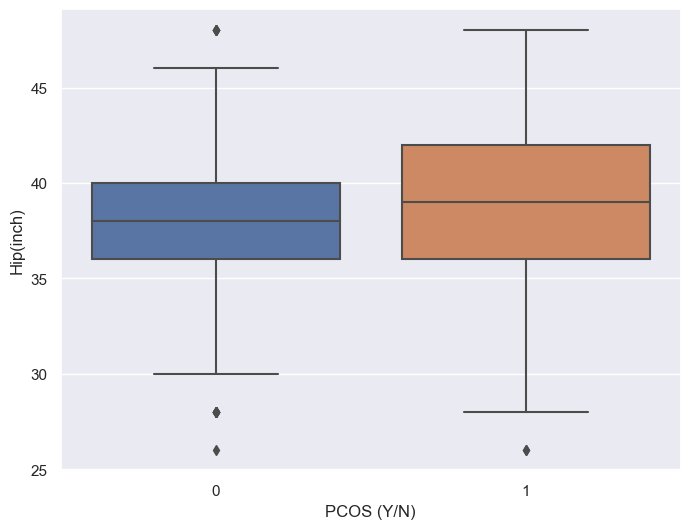

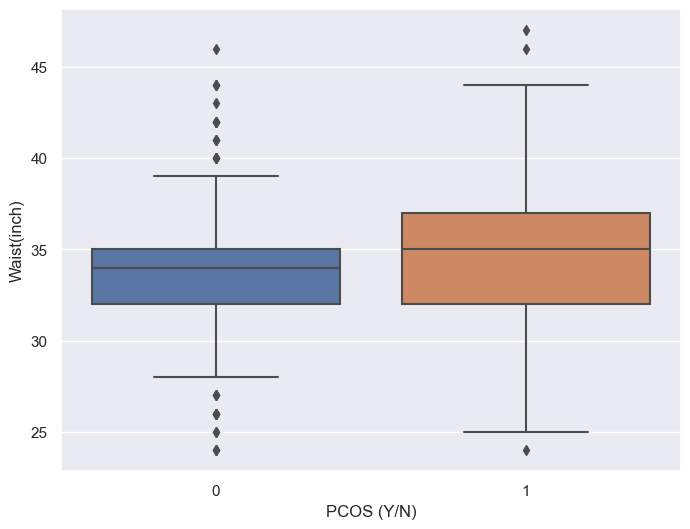

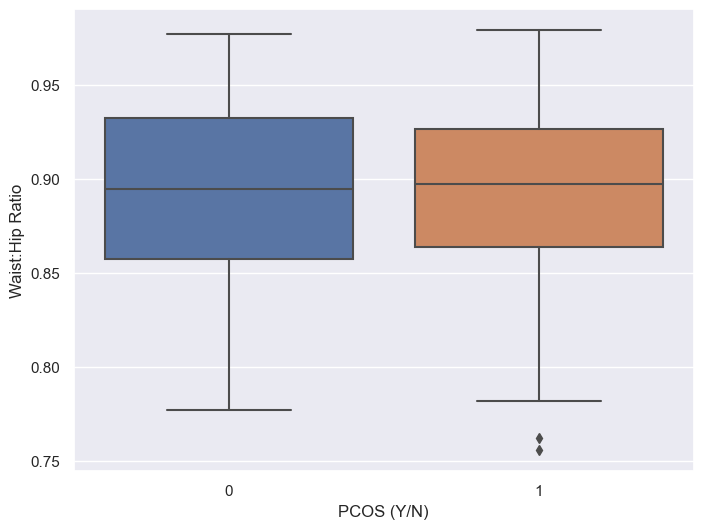

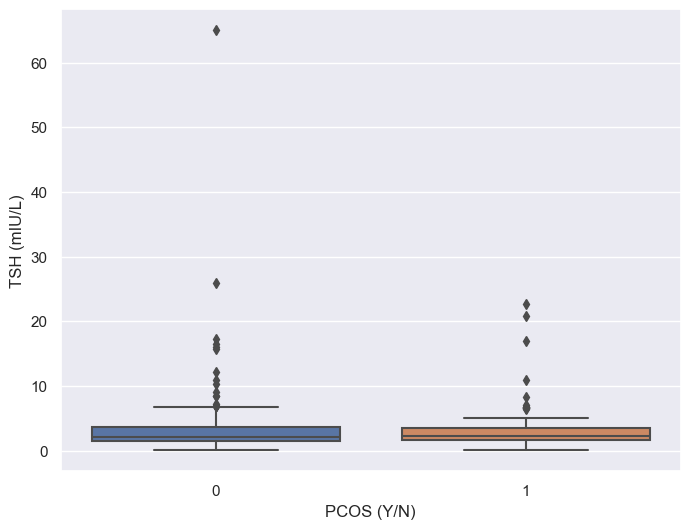

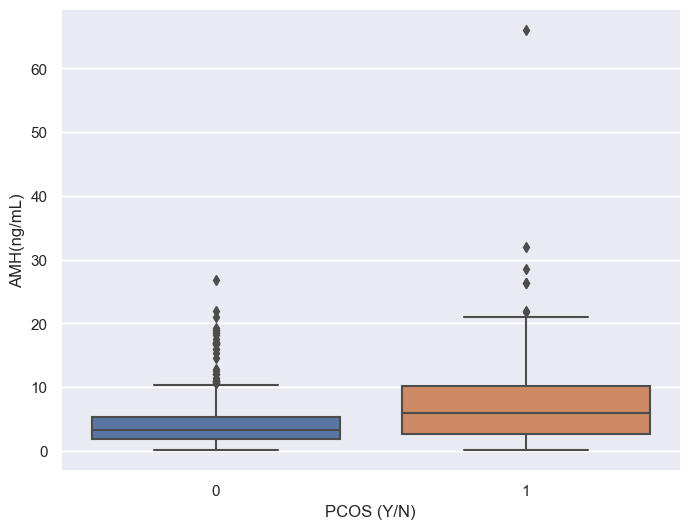

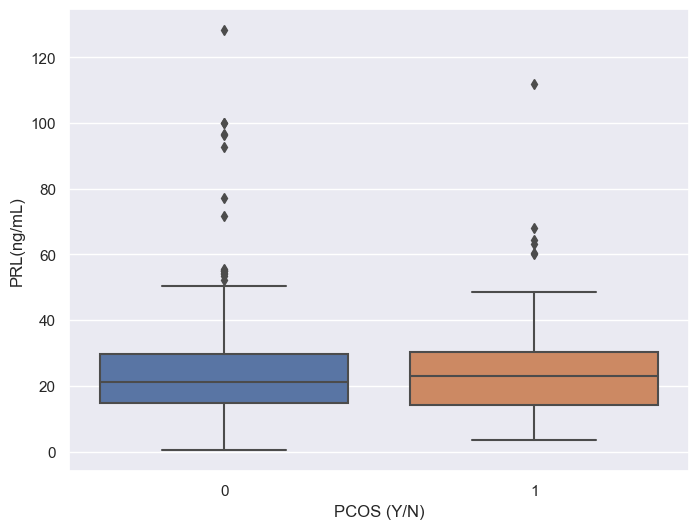

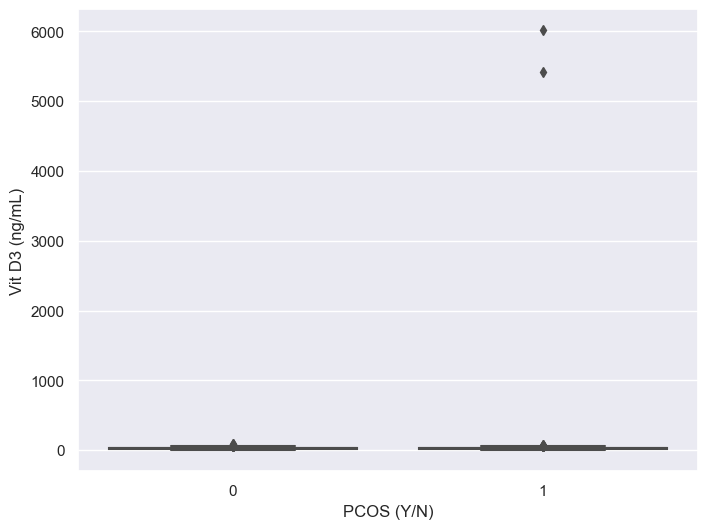

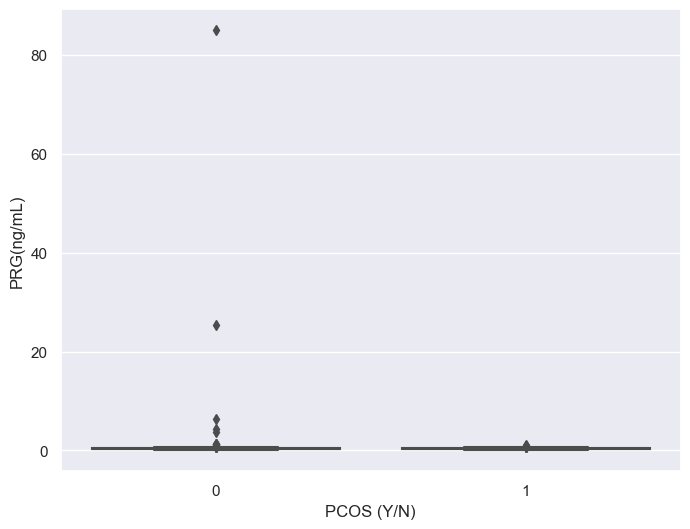

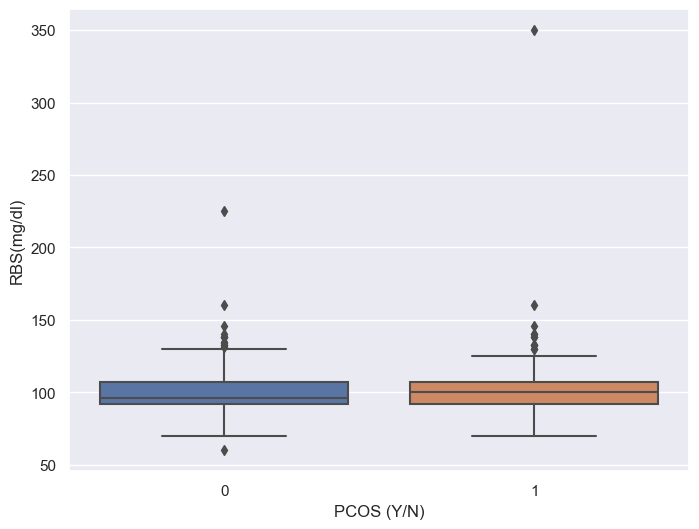

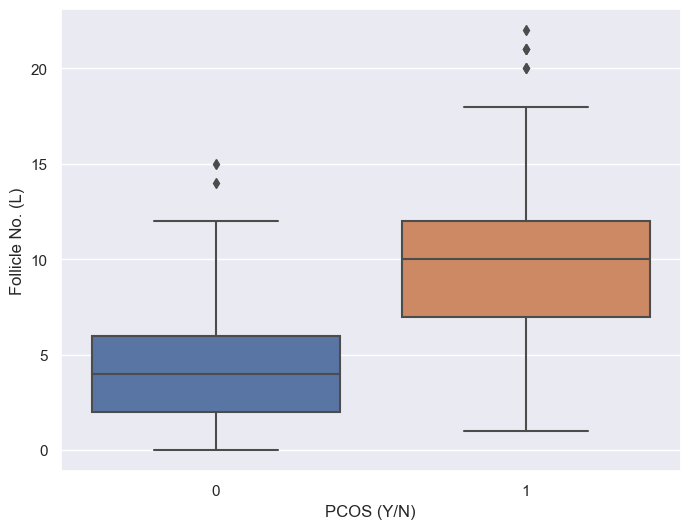

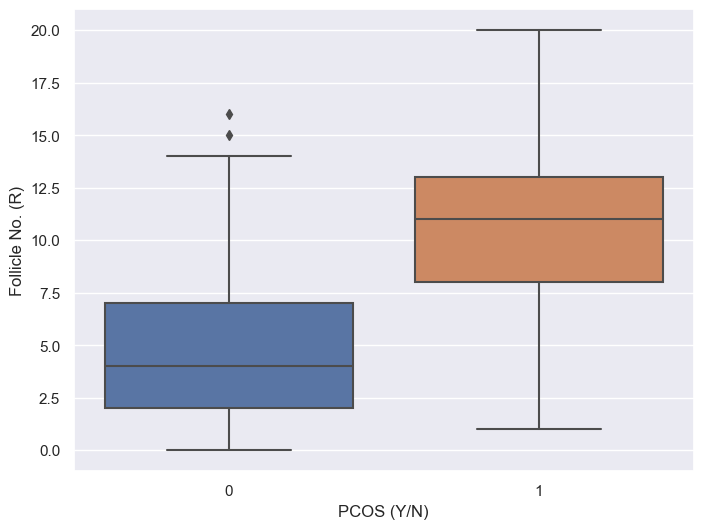

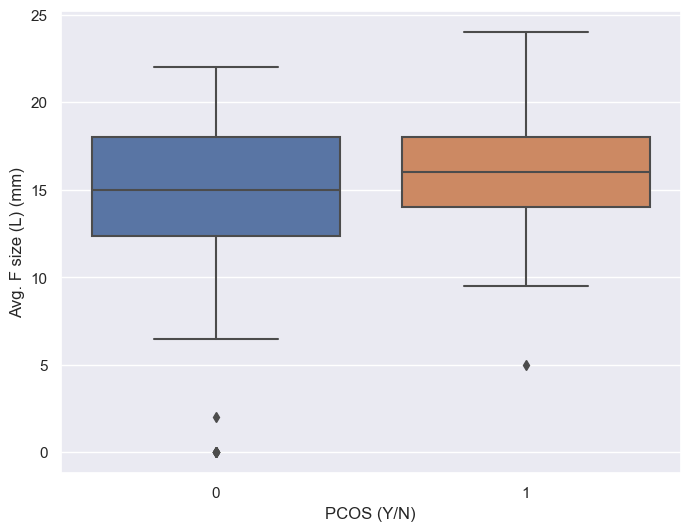

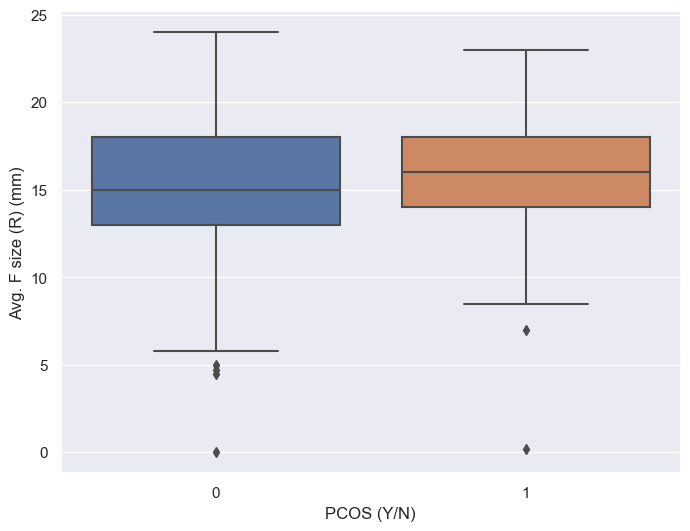

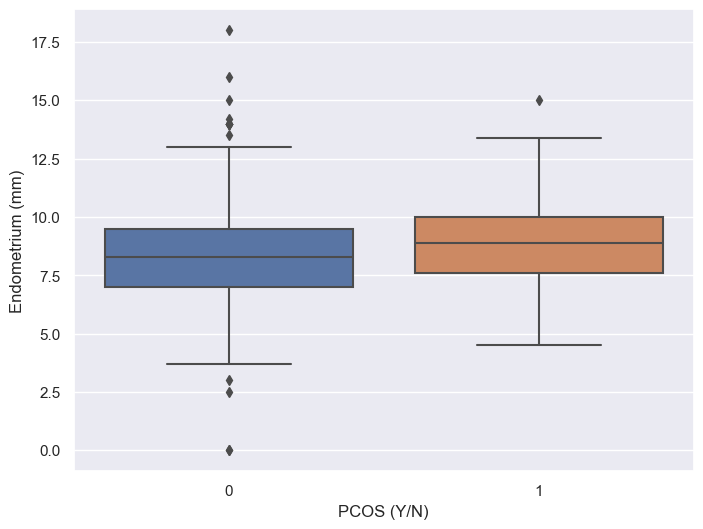

In [34]:
#Plotting Box plot for the numerical variables
for y in numerical_variables:
    sns.boxplot(y=y, x="PCOS (Y/N)", data=df)
    plt.show()

##### Observations from boxplot
higher the follicle number more the tendancy of PCOS
patients with lower cycle lengths means more tendancy of PCOS
the average age of patients diagnosed with PCOS is 30 years


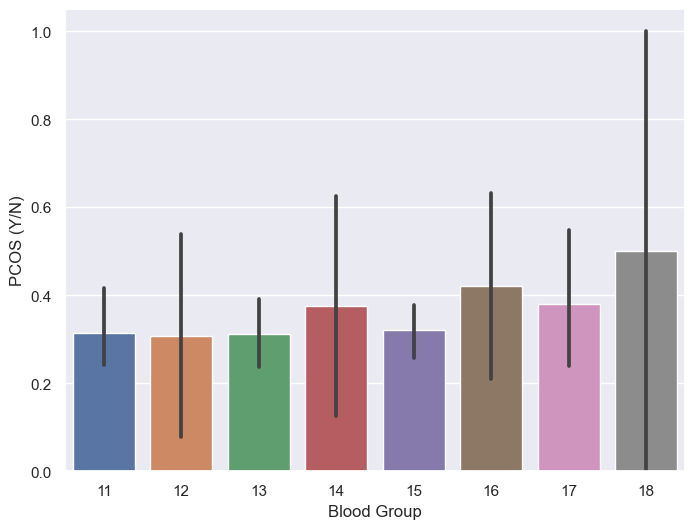

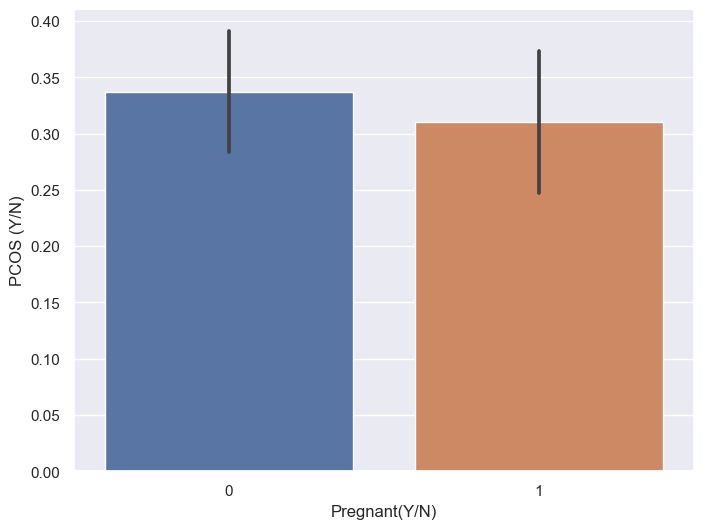

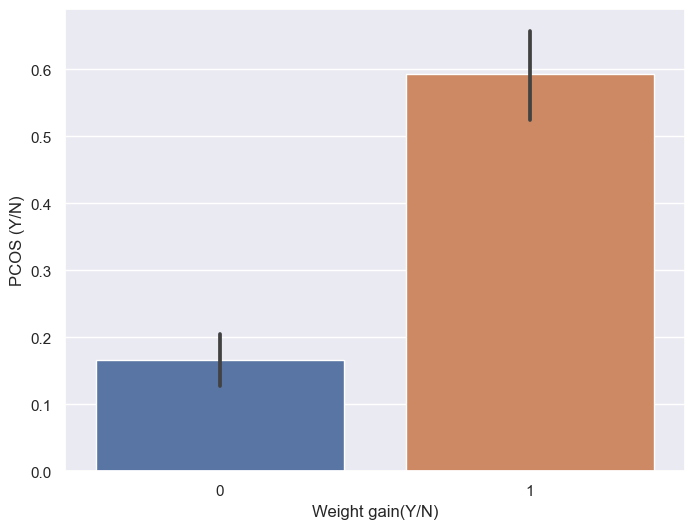

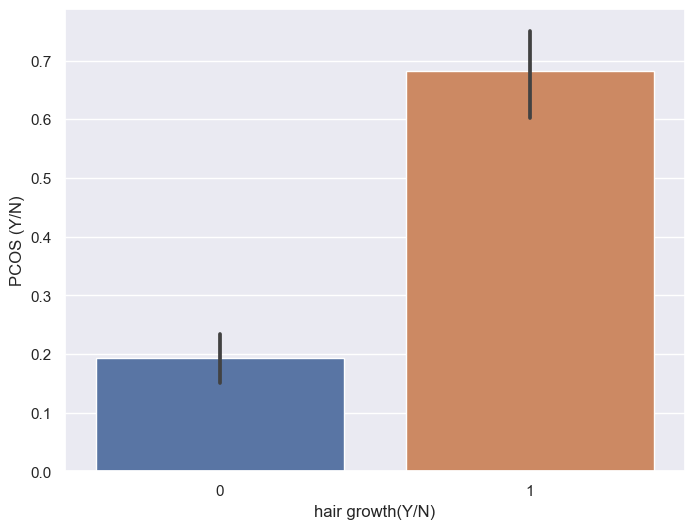

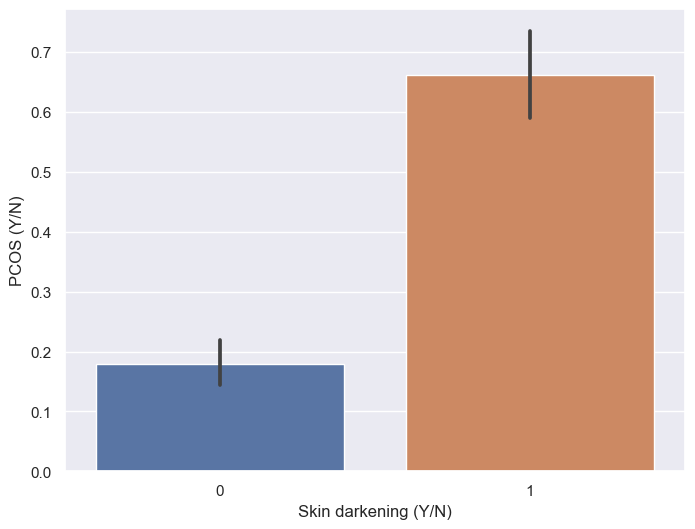

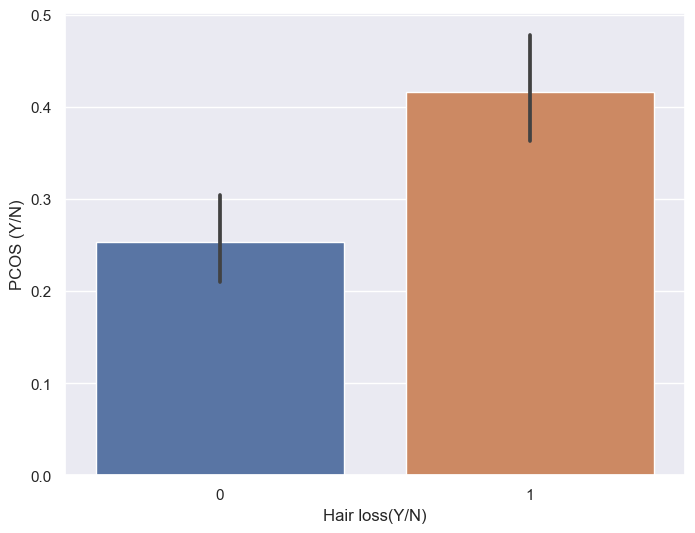

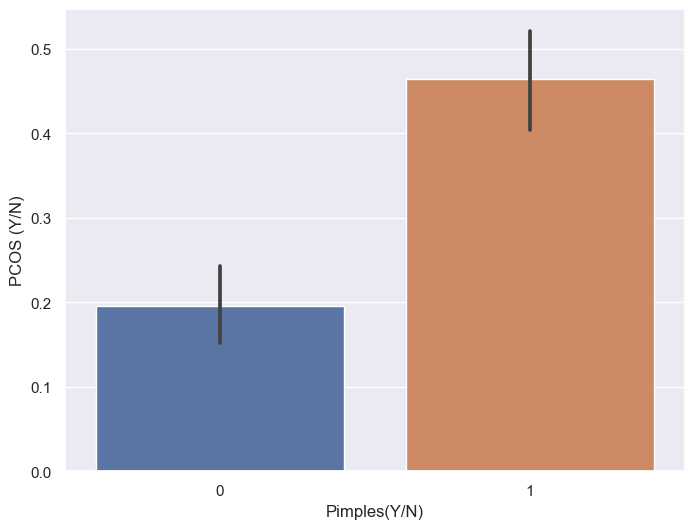

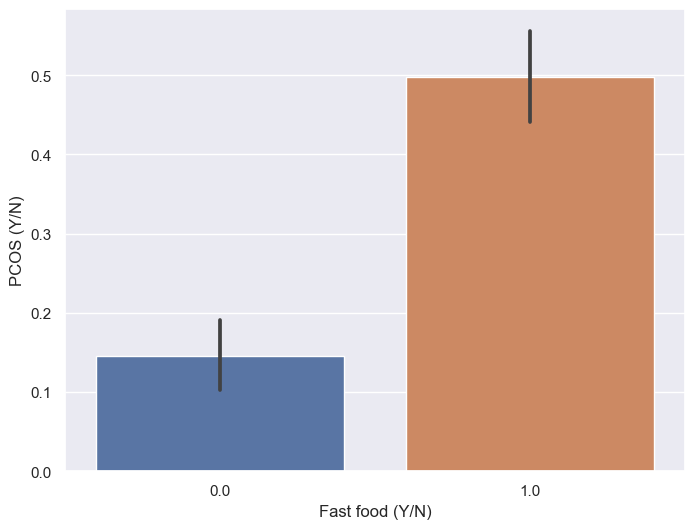

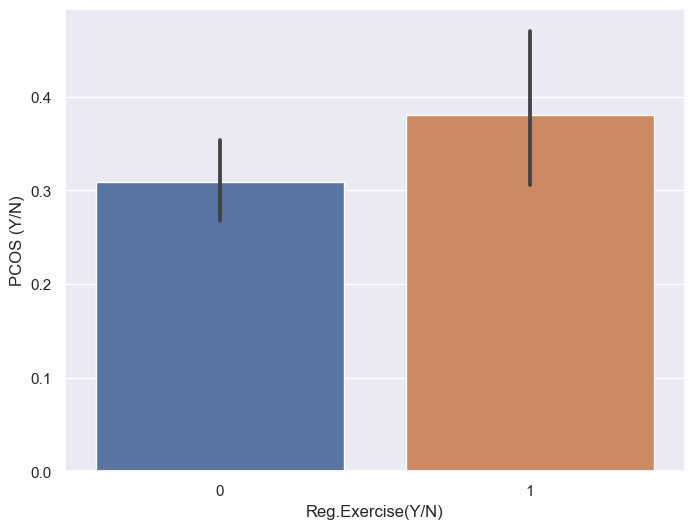

In [35]:
for x in categorical_variables:
    if x != "PCOS (Y/N)":
        sns.barplot(x= x, y = "PCOS (Y/N)", data = df)
        plt.show()

#### Observations from barplot- 
weight gain, hair growth, pipmles, hair loss, fast food and skin darkening means higher chances of PCOS**.
So the above can also be termed as symptoms of PCOS

<Axes: xlabel='PCOS (Y/N)', ylabel='count'>

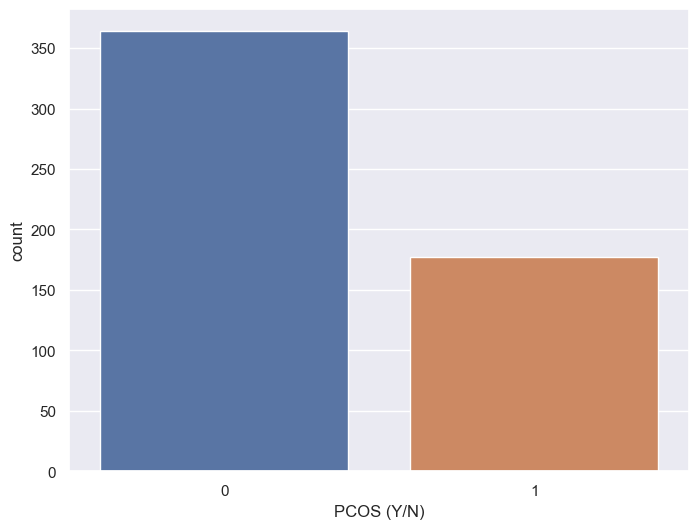

In [36]:
sns.countplot(x = "PCOS (Y/N)", data = df)

In [37]:
df["PCOS (Y/N)"].value_counts()

0    364
1    177
Name: PCOS (Y/N), dtype: int64

In [38]:
177/(364 + 177)*100

32.71719038817005

32 % of patients in our dataset are those having PCOS syndrome

#### Classification using Linear Models

In [39]:
df


,PCOS (Y/N),Age (yrs),Weight (Kg),Height(Cm),BMI,Blood Group,Pulse rate(bpm),RR (breaths/min),Hb(g/dl),Cycle(R/I),...,Pimples(Y/N),Fast food (Y/N),Reg.Exercise(Y/N),BP _Systolic (mmHg),BP _Diastolic (mmHg),Follicle No. (L),Follicle No. (R),Avg. F size (L) (mm),Avg. F size (R) (mm),Endometrium (mm)
0,0,28,44.6,152.000,19.300000,15,78,22,10.48,2,...,0,1.0,0,110,80,3,3,18.0,18.0,8.5
1,0,36,65.0,161.500,24.921163,15,74,20,11.70,2,...,0,0.0,0,120,70,3,5,15.0,14.0,3.7
2,1,33,68.8,165.000,25.270891,11,72,18,11.80,2,...,1,1.0,0,120,80,13,15,18.0,20.0,10.0
3,0,37,65.0,148.000,29.674945,13,72,20,12.00,2,...,0,0.0,0,120,70,2,2,15.0,14.0,7.5
4,0,25,52.0,161.000,20.060954,11,72,18,10.00,2,...,0,0.0,0,120,80,3,4,16.0,14.0,7.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
536,0,35,50.0,164.592,18.500000,17,72,16,11.00,2,...,0,0.0,0,110,70,1,0,17.5,10.0,6.7
537,0,30,63.2,158.000,25.300000,15,72,18,10.80,2,...,0,0.0,0,110,70,9,7,19.0,18.0,8.2
538,0,36,54.0,152.000,23.400000,13,74,20,10.80,2,...,0,0.0,0,110,80,1,0,18.0,9.0,7.3
539,0,27,50.0,150.000,22.200000,15,74,20,12.00,4,...,1,0.0,0,110,70,7,6,18.0,16.0,11.5


In [40]:
y = df.iloc[:, 0]


In [41]:
X = df.iloc[:, 1:]

In [63]:
#CLASSIFICATION USING LOGISTIC REGRESSION
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, precision_recall_curve, f1_score
from sklearn import metrics
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score

In [55]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)
logreg = LogisticRegression()
logreg.fit(X_train, y_train)
y_pred = logreg.predict(X_test)

In [56]:
print('Accuracy of logistic regression classifier on test set: {:.2f}'.format(logreg.score(X_test, y_test)))

Accuracy of logistic regression classifier on test set: 0.85


In [57]:
from sklearn.metrics import classification_report
print('\nThe evaluation parameters are : \n',classification_report(y_test, y_pred))



The evaluation parameters are : 
               precision    recall  f1-score   support

           0       0.89      0.88      0.88       109
           1       0.76      0.78      0.77        54

    accuracy                           0.85       163
   macro avg       0.83      0.83      0.83       163
weighted avg       0.85      0.85      0.85       163



In [62]:
# Calculate Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, logreg.predict_proba(X_test)[:, 1])
# Calculate F1-score
f1 = f1_score(y_test, y_pred)
# Calculate Accuracy
accuracy = accuracy_score(y_test, y_pred)

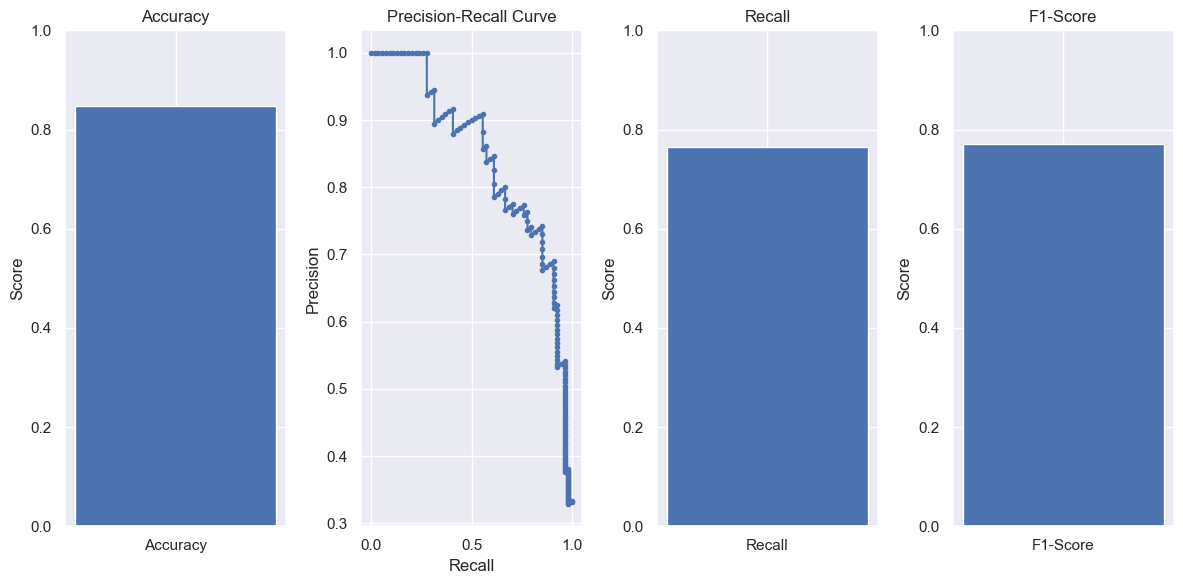

In [65]:
# Plot Accuracy, Precision, Recall, and F1-Score
plt.figure(figsize=(12, 6))

# Plot Accuracy
plt.subplot(1, 4, 1)
plt.bar(['Accuracy'], [accuracy])
plt.ylim(0, 1)
plt.ylabel('Score')
plt.title('Accuracy')

# Plot Precision-Recall Curve
plt.subplot(1, 4, 2)
plt.plot(recall, precision, marker='.')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')

# Plot Recall
plt.subplot(1, 4, 3)
plt.bar(['Recall'], [recall.mean()])
plt.ylim(0, 1)
plt.ylabel('Score')
plt.title('Recall')

# Plot F1-Score
plt.subplot(1, 4, 4)
plt.bar(['F1-Score'], [f1])
plt.ylim(0, 1)
plt.ylabel('Score')
plt.title('F1-Score')

plt.tight_layout()
plt.show()

In [67]:
#CLASSIFICATION USING SVM(Support Vector Machine)
from sklearn import svm

In [68]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)
clf = svm.SVC()
clf.fit(X_train, y_train)

SVC()

In [69]:
y_pred = clf.predict(X_test)
print('Accuracy of SVM classifier on test set: {:.2f}'.format(clf.score(X_test, y_test)))

Accuracy of SVM classifier on test set: 0.67


In [70]:
confusion_matrix = confusion_matrix(y_test, y_pred)

In [71]:
from sklearn.metrics import classification_report
print('\nThe evaluation parameters are : \n',classification_report(y_test, y_pred))


The evaluation parameters are : 
               precision    recall  f1-score   support

           0       0.67      1.00      0.80       109
           1       0.00      0.00      0.00        54

    accuracy                           0.67       163
   macro avg       0.33      0.50      0.40       163
weighted avg       0.45      0.67      0.54       163



<Figure size 800x600 with 0 Axes>

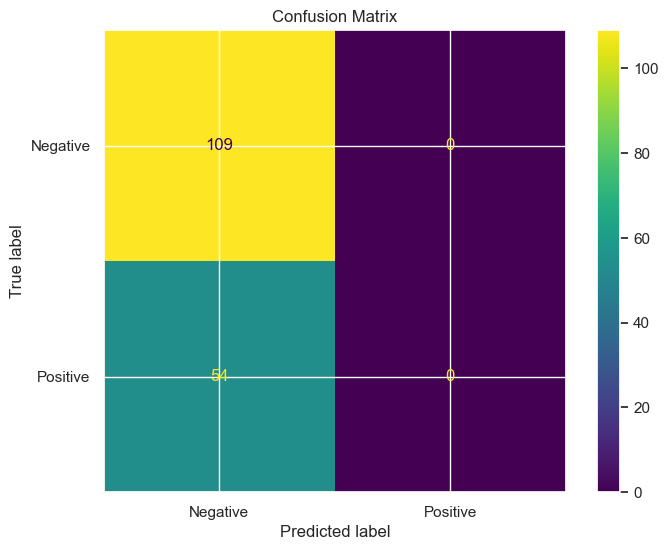

In [75]:
# Graph for Confusion Matrix
plt.figure(figsize=(8, 6))
ConfusionMatrixDisplay.from_estimator(clf, X_test, y_test, display_labels=["Negative", "Positive"])
plt.title("Confusion Matrix")
plt.show()


In [76]:
# Calculate Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, clf.decision_function(X_test))

# Calculate F1-score
f1 = f1_score(y_test, y_pred)

# Calculate Accuracy
accuracy = accuracy_score(y_test, y_pred)


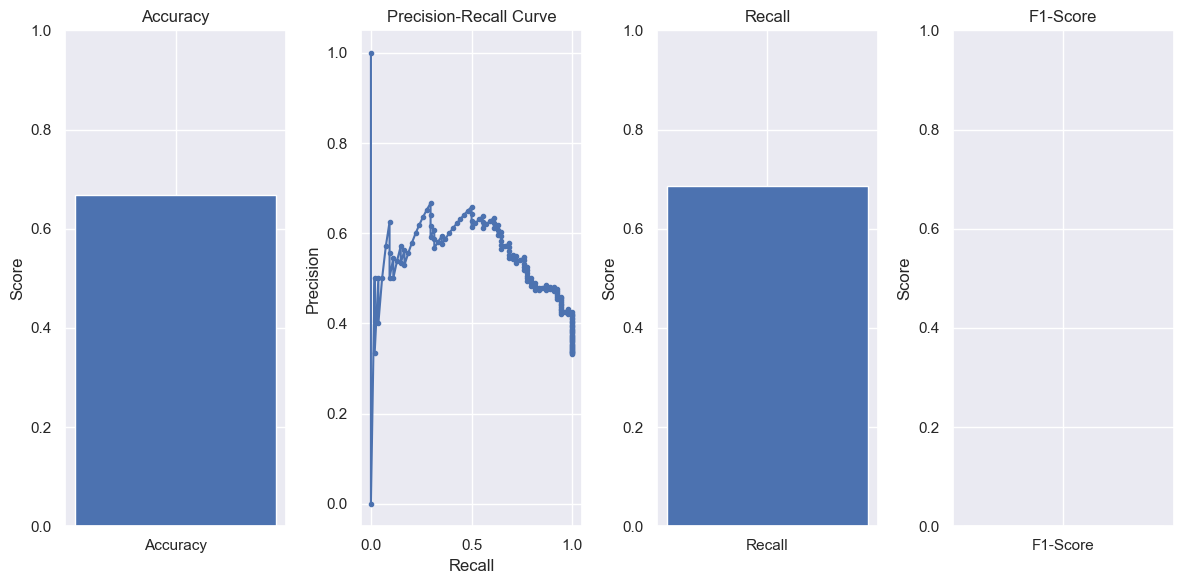

In [77]:
# Plot Accuracy, Precision, Recall, and F1-Score
plt.figure(figsize=(12, 6))

# Plot Accuracy
plt.subplot(1, 4, 1)
plt.bar(['Accuracy'], [accuracy])
plt.ylim(0, 1)
plt.ylabel('Score')
plt.title('Accuracy')

# Plot Precision-Recall Curve
plt.subplot(1, 4, 2)
plt.plot(recall, precision, marker='.')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')

# Plot Recall
plt.subplot(1, 4, 3)
plt.bar(['Recall'], [recall.mean()])
plt.ylim(0, 1)
plt.ylabel('Score')
plt.title('Recall')

# Plot F1-Score
plt.subplot(1, 4, 4)
plt.bar(['F1-Score'], [f1])
plt.ylim(0, 1)
plt.ylabel('Score')
plt.title('F1-Score')

plt.tight_layout()
plt.show()

#### CLASSIFICATION USING NON LINEAR MODELS


In [78]:
#CLASSIFICATION USING NAIVE BAYES
from sklearn.naive_bayes import GaussianNB

In [79]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)
clf = GaussianNB()
clf.fit(X_train, y_train)


GaussianNB()

In [80]:
y_pred = clf.predict(X_test)
print('Accuracy of Naive Bayes classifier on test set: {:.2f}'.format(clf.score(X_test, y_test)))

Accuracy of Naive Bayes classifier on test set: 0.83


In [83]:
print('\nThe evaluation parameters are : \n',classification_report(y_test, y_pred))


The evaluation parameters are : 
               precision    recall  f1-score   support

           0       0.83      0.93      0.88       109
           1       0.81      0.63      0.71        54

    accuracy                           0.83       163
   macro avg       0.82      0.78      0.79       163
weighted avg       0.83      0.83      0.82       163



In [88]:
# Calculate Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, clf.predict_proba(X_test)[:, 1])
# Calculate F1-score
f1 = f1_score(y_test, y_pred)

# Calculate Accuracy
accuracy = accuracy_score(y_test, y_pred)

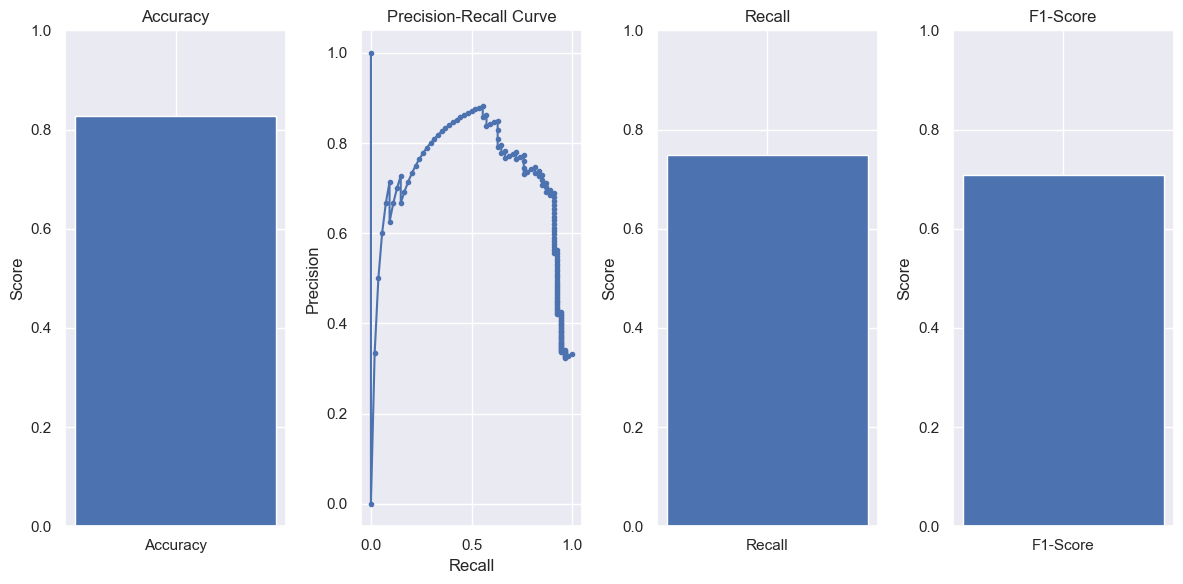

In [89]:
# Plot Accuracy, Precision, Recall, and F1-Score
plt.figure(figsize=(12, 6))

# Plot Accuracy
plt.subplot(1, 4, 1)
plt.bar(['Accuracy'], [accuracy])
plt.ylim(0, 1)
plt.ylabel('Score')
plt.title('Accuracy')

# Plot Precision-Recall Curve
plt.subplot(1, 4, 2)
plt.plot(recall, precision, marker='.')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')

# Plot Recall
plt.subplot(1, 4, 3)
plt.bar(['Recall'], [recall.mean()])
plt.ylim(0, 1)
plt.ylabel('Score')
plt.title('Recall')

# Plot F1-Score
plt.subplot(1, 4, 4)
plt.bar(['F1-Score'], [f1])
plt.ylim(0, 1)
plt.ylabel('Score')
plt.title('F1-Score')

plt.tight_layout()
plt.show()


In [90]:
#CLASSIFICATION USING RANDOM FOREST
from sklearn.ensemble import RandomForestClassifier

In [91]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)
clf = RandomForestClassifier()
clf.fit(X_train, y_train)

RandomForestClassifier()

In [92]:
y_pred = clf.predict(X_test)
print('Accuracy of Random Forest classifier on test set: {:.2f}'.format(clf.score(X_test, y_test)))

Accuracy of Random Forest classifier on test set: 0.92


In [95]:
print('\nThe evaluation parameters are : \n',classification_report(y_test, y_pred))


The evaluation parameters are : 
               precision    recall  f1-score   support

           0       0.92      0.96      0.94       109
           1       0.92      0.83      0.87        54

    accuracy                           0.92       163
   macro avg       0.92      0.90      0.91       163
weighted avg       0.92      0.92      0.92       163



In [96]:
# Calculate Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, clf.predict_proba(X_test)[:, 1])

# Calculate F1-score
f1 = f1_score(y_test, y_pred)

# Calculate Accuracy
accuracy = accuracy_score(y_test, y_pred)

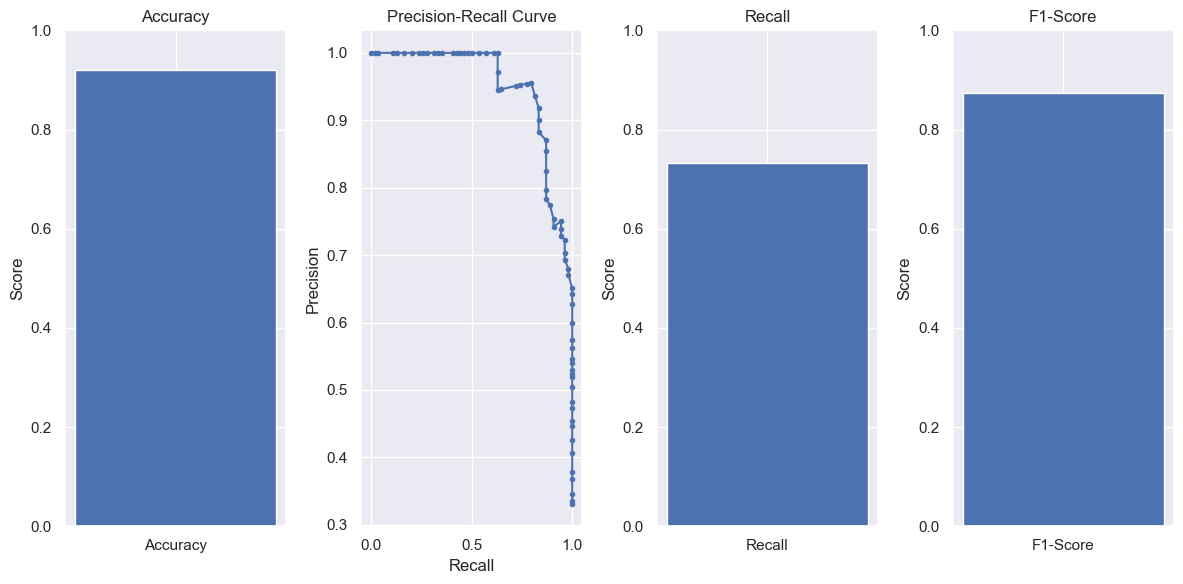

In [97]:
# Plot Accuracy, Precision, Recall, and F1-Score
plt.figure(figsize=(12, 6))

# Plot Accuracy
plt.subplot(1, 4, 1)
plt.bar(['Accuracy'], [accuracy])
plt.ylim(0, 1)
plt.ylabel('Score')
plt.title('Accuracy')

# Plot Precision-Recall Curve
plt.subplot(1, 4, 2)
plt.plot(recall, precision, marker='.')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')

# Plot Recall
plt.subplot(1, 4, 3)
plt.bar(['Recall'], [recall.mean()])
plt.ylim(0, 1)
plt.ylabel('Score')
plt.title('Recall')

# Plot F1-Score
plt.subplot(1, 4, 4)
plt.bar(['F1-Score'], [f1])
plt.ylim(0, 1)
plt.ylabel('Score')
plt.title('F1-Score')

plt.tight_layout()
plt.show()


In [98]:
#CLASSIFICATION USING K-NEAREST NEIGHBOR
from sklearn.neighbors import KNeighborsClassifier

In [99]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)


In [100]:
accuracy = accuracy_score(y_test, y_pred)
print('Accuracy of K-nearest Neighbor classifier on test set:', accuracy)

Accuracy of K-nearest Neighbor classifier on test set: 0.6748466257668712


In [102]:
print('\nThe evaluation parameters are : \n',classification_report(y_test, y_pred))


The evaluation parameters are : 
               precision    recall  f1-score   support

           0       0.72      0.85      0.78       109
           1       0.52      0.31      0.39        54

    accuracy                           0.67       163
   macro avg       0.62      0.58      0.58       163
weighted avg       0.65      0.67      0.65       163



In [103]:
# Calculate Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, knn.predict_proba(X_test)[:, 1])

# Calculate F1-score
f1 = f1_score(y_test, y_pred)

# Calculate Accuracy
accuracy = accuracy_score(y_test, y_pred)

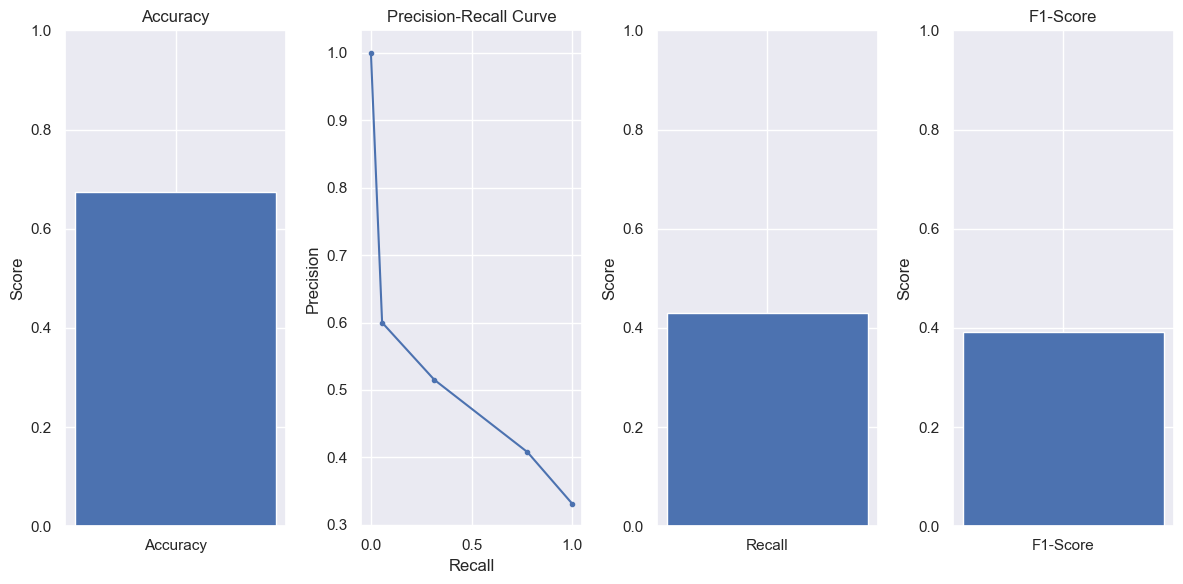

In [104]:
# Plot Accuracy, Precision, Recall, and F1-Score
plt.figure(figsize=(12, 6))

# Plot Accuracy
plt.subplot(1, 4, 1)
plt.bar(['Accuracy'], [accuracy])
plt.ylim(0, 1)
plt.ylabel('Score')
plt.title('Accuracy')

# Plot Precision-Recall Curve
plt.subplot(1, 4, 2)
plt.plot(recall, precision, marker='.')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')

# Plot Recall
plt.subplot(1, 4, 3)
plt.bar(['Recall'], [recall.mean()])
plt.ylim(0, 1)
plt.ylabel('Score')

# Plot F1-Score
plt.subplot(1, 4, 4)
plt.bar(['F1-Score'], [f1])
plt.ylim(0, 1)
plt.ylabel('Score')
plt.title('F1-Score')

plt.tight_layout()
plt.show()

In [107]:
#CLASSIFICATION USING DECISION TREE
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [108]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

DecisionTreeClassifier()

In [109]:
y_pred = dt.predict(X_test)
print('Accuracy of Decision Tree classifier on test set: {:.2f}'.format(dt.score(X_test, y_test)))


Accuracy of Decision Tree classifier on test set: 0.79


In [111]:
print('\nThe evaluation parameters are : \n',classification_report(y_test, y_pred))


The evaluation parameters are : 
               precision    recall  f1-score   support

           0       0.82      0.87      0.84       109
           1       0.70      0.61      0.65        54

    accuracy                           0.79       163
   macro avg       0.76      0.74      0.75       163
weighted avg       0.78      0.79      0.78       163



In [112]:
# Calculate Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, dt.predict_proba(X_test)[:, 1])

# Calculate F1-score
f1 = f1_score(y_test, y_pred)

# Calculate Accuracy
accuracy = accuracy_score(y_test, y_pred)

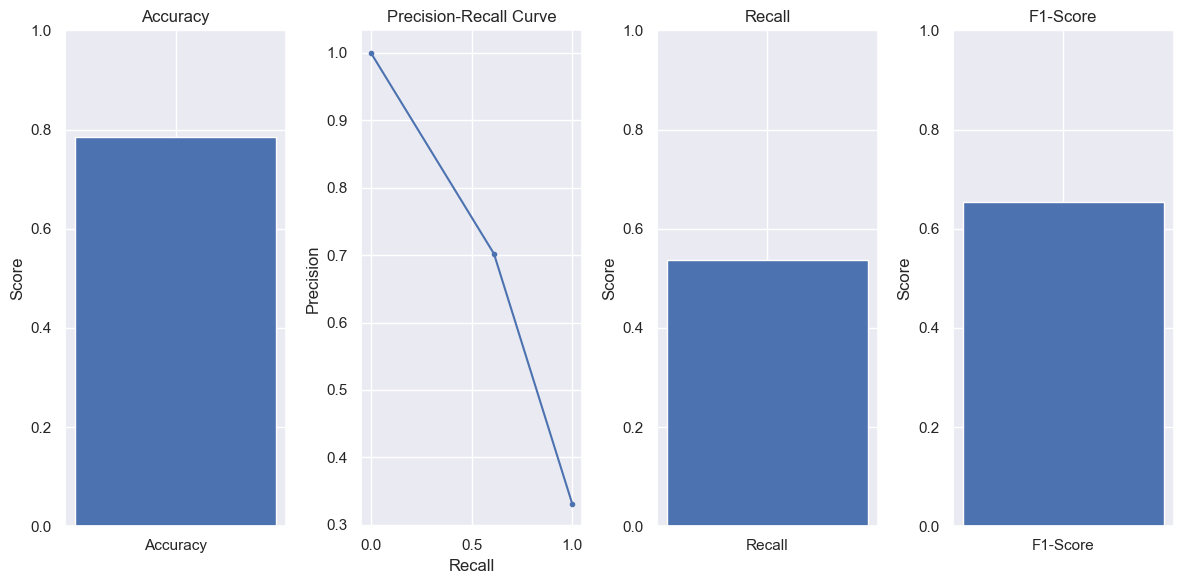

In [114]:
# Plot Accuracy, Precision, Recall, and F1-Score
plt.figure(figsize=(12, 6))

# Plot Accuracy
plt.subplot(1, 4, 1)
plt.bar(['Accuracy'], [accuracy])
plt.ylim(0, 1)
plt.ylabel('Score')
plt.title('Accuracy')

# Plot Precision-Recall Curve
plt.subplot(1, 4, 2)
plt.plot(recall, precision, marker='.')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')

# Plot Recall
plt.subplot(1, 4, 3)
plt.bar(['Recall'], [recall.mean()])
plt.ylim(0, 1)
plt.ylabel('Score')
plt.title('Recall')

# Plot F1-Score
plt.subplot(1, 4, 4)
plt.bar(['F1-Score'], [f1])
plt.ylim(0, 1)
plt.ylabel('Score')
plt.title('F1-Score')

plt.tight_layout()
plt.show()

In [115]:
#CLASSIFICATION USING XGBOOST
import xgboost as xgb

In [116]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

In [117]:
# Convert the data into DMatrix format
dtrain = xgb.DMatrix(X_train, label=y_train)
dtest = xgb.DMatrix(X_test, label=y_test)

In [118]:
# Set the parameters for XGBoost
params = {
    'max_depth': 3,
    'eta': 0.1,
    'objective': 'multi:softmax',
    'num_class': 3
}


In [119]:
# Train the XGBoost model
num_rounds = 10
model = xgb.train(params, dtrain, num_rounds)

In [120]:
# Make predictions on the testing data
y_pred = model.predict(dtest)

# Convert the predictions to integers
y_pred = y_pred.astype(int)

In [121]:
# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print('Accuracy of XGBoost classifier on test set:', accuracy)

Accuracy of XGBoost classifier on test set: 0.8650306748466258


In [123]:
print('\nThe evaluation parameters are : \n',classification_report(y_test, y_pred))


The evaluation parameters are : 
               precision    recall  f1-score   support

           0       0.87      0.94      0.90       109
           1       0.86      0.70      0.78        54

    accuracy                           0.87       163
   macro avg       0.86      0.82      0.84       163
weighted avg       0.86      0.87      0.86       163



In [125]:
# Calculate Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, model.predict(dtest))

# Calculate F1-score
f1 = f1_score(y_test, y_pred, average='weighted')

# Calculate Accuracy
accuracy = accuracy_score(y_test, y_pred)

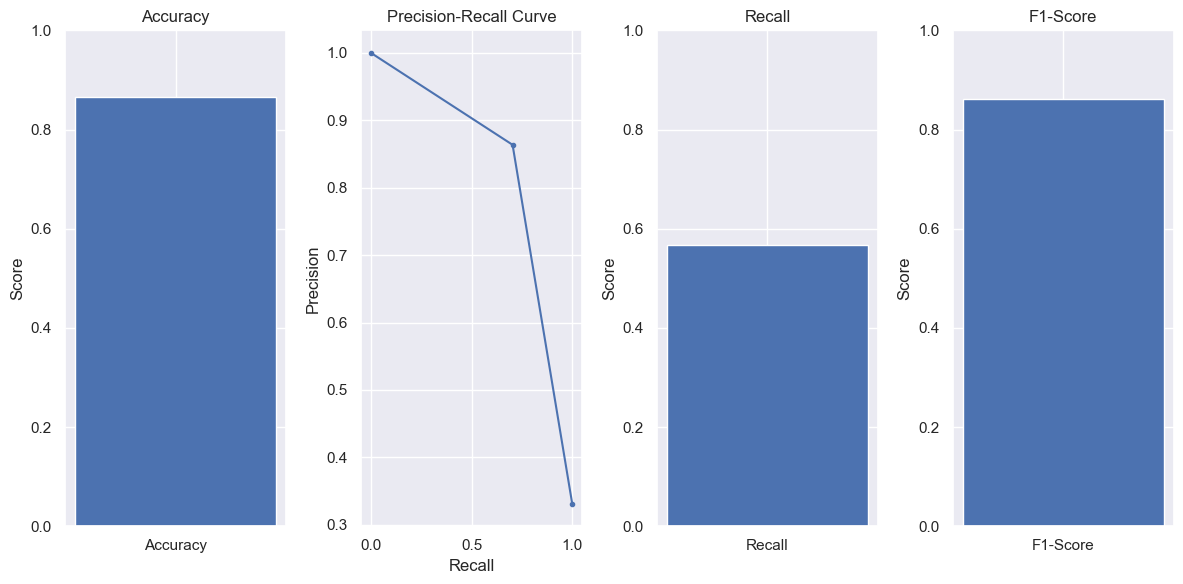

In [126]:
# Plot Accuracy, Precision, Recall, and F1-Score
plt.figure(figsize=(12, 6))
# Plot Accuracy
plt.subplot(1, 4, 1)
plt.bar(['Accuracy'], [accuracy])
plt.ylim(0, 1)
plt.ylabel('Score')
plt.title('Accuracy')

# Plot Precision-Recall Curve
plt.subplot(1, 4, 2)
plt.plot(recall, precision, marker='.')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')

# Plot Recall
plt.subplot(1, 4, 3)
plt.bar(['Recall'], [recall.mean()])
plt.ylim(0, 1)
plt.ylabel('Score')
plt.title('Recall')

# Plot F1-Score
plt.subplot(1, 4, 4)
plt.bar(['F1-Score'], [f1])
plt.ylim(0, 1)
plt.ylabel('Score')
plt.title('F1-Score')

plt.tight_layout()
plt.show()

In [128]:
# Create instances of all models
models = {
    "Logistic Regression": LogisticRegression(),
    "Naive Bayes": GaussianNB(),
    "Random Forest": RandomForestClassifier(),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=3),
    "Decision Tree": DecisionTreeClassifier(),
    "XGBoost": xgb.XGBClassifier()
}

In [129]:
best_model = None
best_accuracy = 0

for model_name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    print(f'Accuracy of {model_name} classifier on test set: {accuracy:.2f}')
    
    if accuracy > best_accuracy:
        best_accuracy = accuracy
        best_model = model_name

print(f'\nThe best model is {best_model} with an accuracy of {best_accuracy:.2f}')

Accuracy of Logistic Regression classifier on test set: 0.85
Accuracy of Naive Bayes classifier on test set: 0.83
Accuracy of Random Forest classifier on test set: 0.92
Accuracy of K-Nearest Neighbors classifier on test set: 0.67
Accuracy of Decision Tree classifier on test set: 0.80
Accuracy of XGBoost classifier on test set: 0.89

The best model is Random Forest with an accuracy of 0.92
